<!-- PUBLIC_NOTEBOOK_INTRO -->
# Walking Policy Analysis

Ovaj notebook je pisan kao izvestaj za citaoca koji ne mora da zna sve detalje koda. Ideja je jednostavna: uzeli smo vise treniranih PPO politika, izabrali najbolji checkpoint iz svakog uspesnog run-a i proverili kako se ponasaju u istim kontrolisanim scenarijima hodanja.

Analiza ne pokusava da proglasi pobednika samo na osnovu trening reward-a. Kod humanoidnog hoda to ume da zavara, jer policy moze da dobije dobar broj tako sto klizi, pada u cudnu pozu ili koristi kontaktni trik. Zato ovde zajedno gledamo stabilnost, padove, pracenje joystick komandi, uspravnost trupa, glatkocu akcija, potrosnju aktuatora i oblik trajektorije.

Najvaznije pitanje za publiku je: **da li model zaista hoda bolje, ili samo uspeva da sakupi reward?** Zato su ispod gustih grafikona dodate filtrirane top-4 verzije i kratka tumacenja rezultata.


<!-- PROJECT_CONTEXT_FOR_AUDIENCE -->
## Project Context For The Reader

Pre rezultata je korisno znati sta se zapravo poredi. Berkeley humanoid je pripremljen locomotion benchmark: telo, kontakti, observation prostor, reward i PPO setup su vec pogodni za hodanje. Generated biomechanics human je drugaciji problem: anatomski je interesantniji, ali nije automatski lak za RL. Zato dobar rezultat ovde ne znaci samo visok reward, nego i manje klizanja, manje padova i bolji kontakt stopala sa podom.

### Kratak narativ

- Berkeley baseline pokazuje kako izgleda kada je humanoidni locomotion task vec dobro pripremljen.
- Generated biomechanics model pokazuje istrazivacki deo: morali smo da podesavamo XML, joint limits, actuators, rewards, contact geometrije, BVH reference i metrike.
- Najvazniji zakljucak iz dosadasnjih run-ova je da **velocity tracking sam ne garantuje prirodan hod**. Ako reward ne kaznjava klizanje i los swing/stance ciklus, policy moze da pronadje precicu.
- Zbog toga analiza ispod ne rangira samo reward, nego zajedno gleda survival, tracking, posture, smoothness, power i actuator dijagnostiku.

<details>
<summary>Full imported note: Berkeley vs generated biomechanics walking</summary>

Ovaj dokument je kratak teorijski rezime trenutnog stanja projekta: zasto je
Berkeley humanoid radio mnogo lakse, zasto generated biomechanics human teze
dolazi do lepog hoda, i sta je razuman sledeci korak bez beskonacnog
produbljivanja.

## Trenutni zakljucak

Trenutni generated human rezultat je dobar kao proof-of-concept:

- model se generise kao MuJoCo/MJX humanoid,
- PPO policy se trenira,
- checkpoint moze da se nastavi preko `--resume-from`,
- forward walking je naucen,
- standard joystick fine-tune daje kretanje u vise pravaca,
- model nije "mrtav" i ne krece od nule.

Ali trenutni rezultat nije jos dokaz prirodnog humanoidnog hoda. Video pokazuje
da policy ume da dobije reward, ali cesto koristi kontaktni trik: telo se krece
uz klizanje stopala i neprirodan nagib, umesto jasnog swing/stance ciklusa.

To je normalna RL pojava: ako reward ne kaze dovoljno jasno "ovo mora da lici na
hod", policy ce naci najjeftiniji fizicki nacin da dobije brzinu i stabilnost.

## Zasto je Berkeley radio toliko lako

Berkeley/Barkley rezultat nije bio samo "isti problem sa manje truda". To je bio
mnogo pripremljeniji problem.

### 1. Berkeley model je vec dizajniran za locomotion

Berkeley humanoid iz MuJoCo Playground-a je model koji je vec napravljen da bude
dobar RL benchmark:

- stabilne mase i inercije,
- razumni joint limits,
- dobro podeseni actuatori,
- kontaktne geometrije koje ne prave previse cudne lokalne optimume,
- reset poza koja je pogodna za hod,
- reward i observation dizajnirani za taj model.

Generated biomechanics human nije isto to. On je anatomski zanimljiviji, ali nije
automatski "learning friendly". Ima vise mesta gde policy moze da nadje los trik:
glava/pasivni zglobovi, stopala, padding, odnos mase i momenta, visina root-a,
kontakt sa podom, slabiji ili cudno skalirani actuatori.

### 2. Berkeley env vec ima dobro namesten task

Kod Berkeley prototipa si koristio env koji vec dolazi sa pripremljenim
locomotion setupom:

- joystick command je vec deo zadatka,
- PPO konfiguracija je vec tuned,
- observation prostor je smislen,
- action smoothing i PD targeti su vec u dobrom opsegu,
- reward je vec uskladjen sa tim telom,
- termination uslovi su vec provereni.

Kod generated human-a mi smo morali sve to da napravimo sami. To znaci da svaki
detalj moze da bude pogresan za 10 posto, a tih 10 posto se u RL-u brzo pretvori
u "naucio je cudan hod".

### 3. Berkeley je resavao laksi fizicki problem

Berkeley humanoid je vise roboticki benchmark. Takvi modeli cesto imaju:

- krace i cistije kontaktne lance,
- manje problematicne pasivne delove,
- jasnije actuatorske poluge,
- manje anatomskih izuzetaka,
- bolji odnos snage i mase.

Generated human je blizi stvarnom telu, ali to ne znaci da je laksi za RL. Cesto
je tezi bas zato sto fizika dozvoljava vise neprijatnih polu-resenja.

### 4. Reward-only hod prirodno pravi "zombie walk"

Ako reward kaze:

- budi ziv,
- idi trazenom brzinom,
- ne trosi previse akcije,
- drzi visinu,

onda policy ne mora da nauci lep ljudski hod. Mora samo da maksimizuje brojeve.
Ako moze da klizi, gura pelvis, savije torzo i ipak dobije tracking reward, on ce
to uraditi.

Berkeley model verovatno ima manje takvih rupa, pa isti tip reward-a izgleda
mnogo bolje.

## Sta trenutni generated model stvarno dokazuje

Trenutni rezultat dokazuje ovo:

- pipeline radi od generated modela do PPO treninga,
- 18-actuator setup je trenabilan,
- forward pretraining ima smisla,
- joystick fine-tune nije nemoguc,
- checkpoint transfer radi,
- reward signal je dovoljno informativan da policy nauci kretanje.

Ne dokazuje jos:

- prirodan ljudski gait,
- stabilan hod bez klizanja,
- kvalitetan lateralni/backward joystick,
- robustnost na perturbacije,
- profesor-ready animaciju.

Ovo je vazna razlika. Rezultat nije neuspeh, ali ga ne treba prodati kao finalni
realistican hod.

## Najnoviji BVH tier1 rezultat

BVH reference gait je uveden kao sledeci korak posle sine/style reward-a. To je
tehnicki ispravan pravac jer policy vise ne dobija samo cilj "idi napred", nego i
target joint-angle obrazac iz ljudskih walking clipova.

Run:

```text
runs/biomechanics_noerfi_nodr_forward_ref_bvh_bvh_tier1_accurate_ppo_BiomechanicsHumanJoystickStandard_20260617_2118_60m_seed7_rew_1492p6453_best_1493p6858_s
```

Rezultat je paradoksalno dobar broj, ali los vizuelni hod:

- reward oko `1493`,
- epizode uglavnom pune duzine,
- `foot_slip` ostaje visok,
- `swing_drag` se saturira oko maksimuma,
- stopala vizuelno klize.

Zakljucak: BVH joint-angle reference nije dovoljan sam. Policy moze da lici na
neke uglove iz hoda, a da stopala i dalje nemaju fizicki uverljiv kontakt. Zato
sledeci korak mora biti anti-slip/contact-aware reward ili puniji mocap imitation
koji prati i foot/root kinematiku, ne samo zglobove.

Naknadni code review je nasao jos jaci problem: BVH target nije bio deo policy
observation-a. Drugim recima, reward je trazio pracenje random BVH clip/frame-a,
ali policy nije znala koji clip/frame trenutno treba da imitira. To znaci da
prethodni BVH run nije bio cist test motion imitation-a; zadatak je bio delom
skriven. Novi BVH run mora biti target-conditioned: policy vidi trenutni
retargeted BVH target i no-lift phase je sinhronizovan sa BVH fazom.

## Zakljucak posle DeepMimic/LocoMuJoCo/GMR review-a

Pregled DRLoco, DeepMimic_mujoco, LocoMuJoCo i GMR potvrdjuje da je BVH pravac
ispravan, ali i da "sirovi BVH u sest joint uglova" nije dovoljno jak imitation
signal.

Prakticna razlika:

```text
nas rani BVH setup:
    hip/knee/ankle pose target

DeepMimic/LocoMuJoCo/GMR smer:
    root + qpos + qvel + end-effectors/sites + body targets + reference reset
```

Zato su poslednje promene usmerene na srednji korak:

- dodati root height/velocity target iz BVH-a,
- dodati foot/end-effector target preko MuJoCo FK,
- dodati opcioni reference-state init,
- zadrzati mali `tier1_debug_10.txt` za brze gate testove.

Ovo jos nije pun GMR retargeting. GMR ostaje najbolji sledeci veliki korak ako
treba "pravi" robot motion dataset sa `root_pos`, `root_rot`, `dof_pos` i body
targetima. Ali za trenutni projekat ima smisla prvo proveriti da li ovaj srednji
korak spasava kompatibilni V10 checkpoint.

## Sta dalje

Postoje tri realna pravca.

## Opcija A: zaustaviti produbljivanje i spakovati proof-of-concept

Ovo je najrazumnije ako je cilj da projekat bude zavrsiv.

U tom slucaju bih prikazao:

- Berkeley legacy demo kao "cist, stabilan joystick walking baseline",
- generated human demo kao "custom generated biomechanics model naucen PPO-om",
- jasno ogranicenje: generated gait jos ima contact/style artefakte,
- sledeci rad: motion imitation ili contact-aware gait reward.

Ovo je dobar akademski narativ jer ne krije problem. Pokazuje da si uspeo da
napravis sistem, a ne tvrdi da si resio humanoid locomotion do kraja.

## Opcija B: proceduralni gait/style reward

Ovo je najbolji sledeci korak ako zelis da generated model izgleda bolje, ali ne
zelis odmah mocap.

Ideja: zadrzati joystick reward, ali dodati jace style signale:

- swing foot mora stvarno da se podigne,
- stance foot ne sme da kliza,
- jedna noga je uglavnom stance dok druga ide swing,
- torzo ne sme da pada napred,
- head/upper body treba da ostanu pasivno stabilni,
- action jerk/action rate treba da bude manji,
- pelvis/root ne sme da "vuce" telo dok stopala stoje zalepljena za pod.

Prednost:

- relativno brzo za implementaciju,
- ne treba dataset,
- dobro resava klizanje.

Mana:

- i dalje nije pravi ljudski hod,
- moze da izgleda "roboticki",
- treba pazljivo balansirati reward.

## Opcija C: reference gait ili mocap imitation

Ovo je najbolji pravac ako je cilj profesor-ready, prirodniji hod.

Postoje dve verzije.

### Proceduralni reference gait

Ovo znaci da ne koristis pravi mocap, nego zadatu fazu hoda:

- leva/desna noga imaju sinusoidalnu fazu,
- swing noga ima ciljnu visinu,
- stance noga ima kontakt,
- kuk/koleno/skocni zglob imaju ocekivani obrazac.

To je lakse od mocap-a i moze dosta da smanji zombie/sliding hod.

### Mocap motion imitation

Ovo znaci da imas referentni snimak ili dataset ljudskog hoda i policy dobija
nagradu da lici na taj pokret.

Tipican imitation reward:

- joint pose error,
- joint velocity error,
- end-effector/foot position error,
- root orientation,
- phase matching,
- pose prior/style term.

Prednost:

- najbolja sansa za prirodan hod,
- manje reward hack-ova,
- jasniji cilj: "hoda kao ovaj primer".

Mana:

- treba retargeting na tvoj skeleton,
- treba uskladiti mocap zglobove sa MuJoCo joint imenima,
- treba faza hoda i reset oko reference,
- ako je imitation prejak, policy nece dobro slusati joystick.

Najbolja verzija nije cist mocap i nije cist joystick. Najbolja verzija je
kombinacija:

```text
total_reward =
    joystick_tracking
  + alive/upright/base_height
  + contact/anti-slip
  + motion_style_or_reference_gait
  - action/action_rate costs
```

Drugim recima: joystick kaze gde treba da ide, reference/style kaze kako treba
da izgleda dok ide tamo.

## Moja preporuka

Ne bih sada jurio jos veci reward na istom setupu. Vec si video da veci reward ne
znaci nuzno lep hod.

Najbolji prakticni plan:

1. Sacuvati trenutni best generated checkpoint kao proof-of-concept.
2. Sacuvati Berkeley/Barkley legacy demo kao stabilan baseline.
3. Za finalnu prezentaciju jasno razdvojiti:
   - "baseline koji lepo hoda",
   - "generated model koji je uspesno treniran, ali jos ima gait artefakte".
4. Ako nastavljas razvoj, sledeci ozbiljan korak je hybrid style/imitation:
   - prvo proceduralni gait/style reward,
   - zatim eventualno mocap imitation ako imas vremena.

Ako je cilj da se projekat zavrsi i pokaze profesoru, ne bih odmah ulazio u pun
mocap pipeline. To je novi projekat u projektu.

Ako je cilj da generated human stvarno izgleda dobro, onda mocap/reference gait
ili barem jak proceduralni style reward postaje neizbezan. Reward-only velocity
tracking verovatno nece sam od sebe dati prirodan hod.

## Sta ne bih radio sada

Ne bih sada prvo:

- samo dodavao jos actuatora,
- samo otkljucavao jos kicme,
- samo pustao jos 100M stepova,
- samo pojacavao randomization/ERFI,
- samo jurio najveci reward.

To moze da popravi broj, ali ne mora da popravi hod.

Problem koji se vidi nije "nema dovoljno treninga". Problem je da reward jos ne
opisuje dovoljno dobro stil hoda koji zelimo.

## Kratka verzija za profesora

Berkeley humanoid je posluzio kao kontrolni baseline jer dolazi iz vec
pripremljenog locomotion benchmark-a. Custom generated biomechanics model je tezi
problem jer model, kontakt, actuator scaling, reward i observations nisu unapred
uskladjeni. Trening je uspeo da proizvede joystick locomotion, ali trenutni gait
pokazuje contact/style artefakte. Sledeci naucno opravdan korak je dodavanje
gait-style ili motion-imitation reward-a, jer velocity tracking sam po sebi ne
garantuje prirodan ljudski hod.

</details>

<details>
<summary>Full imported note: optimization and locomotion changes applied</summary>

Ovaj fajl opisuje promene koje su uvedene posle pregleda tvog biomehanickog
humanoid env-a i poredjenja sa referentnim projektima u `.tmp_*` folderima.

Legenda za poreklo:

- `Seen in other projects`: ideja postoji u nekom od pregledanih repo-a.
- `Adapted`: ideja postoji drugde, ali je ovde promenjena zbog naseg XML-a/env-a.
- `Local fix`: uvedeno zbog konkretnog buga ili ogranicenja u ovom projektu.

## Reference Repos Checked

- `.tmp_rishab_humanoid_curriculum_rl`
- `.tmp_ritwik_ddpg_sac_humanoidwalking`
- `.tmp_rohan_lhw`
- `.tmp_roboterax_humanoid_gym`
- `.tmp_jitu_rlmujoco`
- `.tmp_drloco`
- `.tmp_deepmimic_mujoco`
- `.tmp_loco_mujoco`
- `.tmp_gmr`

## High-Level Diagnosis

Stari setup je bio previse tezak za PPO:

- RL je kontrolisao samo 12 leg actuatora.
- Abdomen/pelvis su bili prakticno zakljucani equality constraint-ovima.
- Reward je mogao da nagradi pasivno klizanje i prezivljavanje vise nego pravi hod.
- Policy nije imala gait phase signal, a critic nije imao privileged informacije.
- PPO config je bio mali za ovakav humanoid model.

Drugim recima: nije bilo samo "treba vise koraka". Problem je bio lose postavljen
za ucenje.

## Model / XML Changes

### 1. New XML cache version: `trainfast_v14`

**Files:** `biomechanics_model.py`

**Change:**

- `SCENE_XML_VERSION` je bumpovan na `trainfast_v14`.
- Time se forsira generisanje novog XML-a umesto tihog koriscenja starog v12/v13
  cache-a.

**Source:** Local fix.

**Why:**

- Stari XML je imao trunk lockove.
- v13 je tokom provere uhvacen bez `left_foot_sole/right_foot_sole`, pa je v14
  uveden kao cist cache target.

### 2. Abdomen and pelvis unlocked

**Files:** `biomechanics_model.py`

**Change:**

- Dodati kontrolisani trunk zglobovi:
  - `abdomen_x`
  - `abdomen_y`
  - `abdomen_z`
  - `pelvis_x`
  - `pelvis_y`
  - `pelvis_z`
- Ukupan broj kontrolisanih actuatora je sada 18, ne 12.
- Equality lockovi za abdomen/pelvis se uklanjaju tokom XML build-a.
- Provereno na novom XML-u: `nu=18`, `neq=0`.

**Source:** Adapted.

**Seen in other projects:**

- `Rishab-Agrawal/humanoid-curriculum-rl` i `Jitu0110/RLMujoco` koriste stock
  MuJoCo Humanoid stil gde abdomen ima aktuatore.
- `Jitu0110/RLMujoco/Code/Humanoid_v4.py` dokumentuje abdomen actuators i
  abdomen state u observation-u.

**Local adaptation:**

- Nas generated model ima dodatne pelvis hinge joints. Zato su i pelvis zglobovi
  otkljucani, ali sa manjim opsegom i jacim PD-om da ostanu stiff.

### 3. Stiff trunk joint specs

**Files:** `biomechanics_model.py`

**Change:**

- Abdomen/pelvis vise nisu fiksirani na `-0.001 0.001`.
- Dobili su mali anatomski opseg, damping, stiffness, friction i armature.
- Ideja je: policy sme da koristi trup za balans, ali ne sme da ga pretvori u
  gumeni motor.

**Source:** Adapted.

**Seen in other projects:**

- Rishab custom humanoid XML ima abdomen joints sa damping/stiffness i motorima.
- Stock Humanoid-style env-ovi kontrolisu abdomen.

### 4. Stronger position actuators with joint-specific limits

**Files:** `biomechanics_model.py`

**Change:**

- Uveden `ACTUATOR_SPECS` po joint-u.
- Trunk actuators imaju male `ctrlrange` vrednosti:
  - abdomen oko `0.14-0.18 rad`
  - pelvis oko `0.10-0.12 rad`
- Leg actuators imaju snaznije PD vrednosti nego stari generic `kp=35`.

**Source:** Local adaptation.

**Why:**

- Stari generic actuator setup je bio preslab i previse uniforman.
- Trup mora biti kontrolisan drugacije od kuka/kolena/stopala.

### 5. Compiler angle fix

**Files:** `biomechanics_model.py`

**Change:**

- `compiler angle` se eksplicitno postavlja na `degree`.

**Source:** Local fix.

**Why:**

- Base generated XML joint ranges su u stepenima. Ako se pogresno tretiraju kao
  radijani, model dobije besmislene joint limits.

### 6. Stable foot sole geoms

**Files:** `biomechanics_model.py`

**Change:**

- Dodati/vraceni su:
  - `left_foot_sole`
  - `right_foot_sole`
- To su box geometrije ispod stopala, ne novi zglobovi i ne novi actuatori.
- Koriste se za stabilniji kontakt i za reward signale.

**Source:** Local fix.

**Why:**

- Generated foot capsule geometrije nisu dovoljno jasan kontakt signal za RL.
- v13 provera je pukla jer env ocekuje ova imena za foot reward/critic signal.

### 7. Collision filtering for training

**Files:** `biomechanics_model.py`

**Change:**

- Non-foot geometrije su visual-only za kontakt.
- Teren prima kontakt od foot sole geometrija.

**Source:** Local fix.

**Why:**

- Smanjuje nepotrebne self/contact parove.
- Daje jasniji signal: stopala su primarni kontakt sa podom.

## Environment Changes

### 8. Per-joint action scale

**Files:** `biomechanics_env.py`

**Change:**

- Action scale vise nije jedan broj za sve.
- Trunk ima mali action scale:
  - abdomen: `0.06-0.08`
  - pelvis: `0.04-0.05`
- Leg joints zadrzavaju normalni `action_scale`.

**Source:** Local adaptation.

**Why:**

- Trup treba da balansira sitno, ne da pravi velike pokrete kao noge.

### 9. Reduced trunk torque injection

**Files:** `biomechanics_env.py`

**Change:**

- ERFI/RAO torque injection se skalira po actuatoru.
- Trunk dobija samo `0.2x` torque perturbacije u odnosu na noge.

**Source:** Local adaptation.

**Why:**

- Ako trunk dobije isti random torque kao noge, lako destabilizuje humanoida pre
  nego sto policy nauci osnovni balans.

### 10. Per-actuator reset noise

**Files:** `biomechanics_env.py`

**Change:**

- Reset noise se primenjuje samo na kontrolisane actuators qpos.
- Trunk noise je manji (`0.005`) od leg noise-a (`0.02`).

**Source:** Local adaptation.

### 11. Dict observations: policy state + privileged critic state

**Files:** `biomechanics_env.py`, `train.py`, `evaluate.py`

**Change:**

- Env sada vraca:
  - `state`: observation za policy.
  - `privileged_state`: siri observation za critic.
- Policy state shape: `98`.
- Privileged critic state shape: `151`.

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` koristi privileged observations za critic.
- Njihov runner koristi critic obs ako postoje.

**Local adaptation:**

- U Brax PPO-u je to mapirano kroz:
  - `policy_obs_key="state"`
  - `value_obs_key="privileged_state"`

### 12. Privileged critic signals

**Files:** `biomechanics_env.py`

**Change:**

`privileged_state` ukljucuje dodatno:

- root `qpos[:3]`
- root `qvel[:6]`
- `qfrc_actuator` za kontrolisane DoF-ove
- foot positions
- pseudo foot contact
- action scale vector

**Source:** Adapted.

**Seen in other projects:**

- Stock Humanoid-style env-ovi dokumentuju/use `qfrc_actuator`.
- `Jitu0110/RLMujoco` i `Rishab-Agrawal/humanoid-curriculum-rl` imaju
  Humanoid-v4 style observation dokumentaciju sa actuator/contact signalima.
- `roboterax/humanoid-gym` koristi privileged critic obs.

### 13. Gait phase observation

**Files:** `biomechanics_env.py`

**Change:**

- Policy state sada ukljucuje `sin(phase)` i `cos(phase)`.
- Command slice ostaje `9:12`, tako da evaluator i dalje moze da menja joystick
  komandu bez pomeranja indeksa.

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` koristi gait phase (`sin`, `cos`) i stance masks.
- `.tmp_rohan_lhw` walking tasks koriste phase/clock reward.

### 14. Action smoothing

**Files:** `biomechanics_env.py`, `config.py`, `train.py`, `evaluate.py`

**Change:**

- Policy action se filtrira:
  - `smoothed = action_smoothing * new + (1 - action_smoothing) * previous`
- Default `action_smoothing=0.5`.
- CLI opcija: `--action-smoothing`.

**Source:** Adapted.

**Seen in other projects:**

- Humanoid locomotion projekti cesto filtriraju/clipuju actions ili PD targets.
- `roboterax/humanoid-gym` i sim2sim kod imaju action clipping/torque limiting.

## Reward Changes

### 15. Dense humanoid reward scaffold

**Files:** `biomechanics_env.py`

**Change:**

Reward sada kombinuje:

- alive reward
- velocity tracking
- forward progress gated by tracking
- upright reward
- base height reward
- posture reward
- gait reward
- action cost
- action rate cost
- trunk posture cost
- foot slip cost
- height cost
- overspeed cost
- vertical velocity cost
- angular velocity cost
- stuck penalty
- fall reward

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- Stock Humanoid-style reward: `healthy_reward + forward_reward - ctrl_cost`.
- `Jitu0110/RLMujoco` dodatno pojacava healthy/forward reward i smanjuje ctrl
  cost.
- `ritwikrohan/DDPG-SAC-HumanoidWalking` dodaje standing/forward velocity bonus.

**Local adaptation:**

- Nas zadatak nije samo "idi +x", nego joystick tracking. Zato je forward
  progress vezan za command tracking, a ne puko nagradjivanje brzine.

### 16. Positive reward clipping

**Files:** `biomechanics_env.py`

**Change:**

- Non-terminal reward se clipuje na `[0, 3]`.
- Fall ostaje negativan (`-10`).

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` ima `only_positive_rewards=True` i clip negativnog
  total reward-a pre termination reward-a.

### 17. Softer fall penalty

**Files:** `biomechanics_env.py`

**Change:**

- Fall penalty je smanjen sa ekstremno negativnog na `-10`.

**Source:** Local adaptation.

**Why:**

- Prevelika negativna kazna moze da dominira PPO signalom na pocetku i da napravi
  "ne diraj nista" strategiju.

### 18. Foot slip penalty

**Files:** `biomechanics_env.py`

**Change:**

- Dodata kazna za horizontalno klizanje foot sole geometrija dok su u kontaktu.

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` ima `foot_slip` reward/cost.

### 19. Foot contact / gait reward

**Files:** `biomechanics_env.py`

**Change:**

- Gait reward nagradjuje:
  - swing foot clearance
  - stance foot contact
- Contact je pseudo-contact iz visine `left_foot_sole/right_foot_sole`.

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` koristi gait phase, stance masks, contact rewards i
  foot clearance.
- `.tmp_rohan_lhw` walking task koristi foot force/foot velocity clock rewards.

### 20. Base height and orientation rewards

**Files:** `biomechanics_env.py`

**Change:**

- Dodata mala nagrada za root height blizu pocetne stojece visine.
- Upright signal ostaje deo reward-a.

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- Humanoid/legged locomotion env-ovi tipicno koriste base height/orientation
  stabilizatore.

### 21. Overspeed and stuck penalties

**Files:** `biomechanics_env.py`

**Change:**

- Kazni se prebrzo kretanje u odnosu na command.
- Kazni se stanje gde command trazi hod, a forward velocity ostaje prenizak.

**Source:** Local adaptation.

**Why:**

- Prethodni reward je mogao da nagradi pasivno ubrzanje/klizanje koje nije pravo
  pracenje joystick komande.

## PPO / Training Changes

### 22. Bigger PPO setup for biomechanics humanoid

**Files:** `train.py`

**Change:**

Default biomechanics PPO config:

- `num_timesteps=50_000_000`
- `num_envs=1024`
- `num_eval_envs=32`
- `episode_length=500`
- `learning_rate=3e-4`
- `entropy_cost=3e-3`
- `unroll_length=20`
- `batch_size=512`
- `num_minibatches=8`
- `num_updates_per_batch=4`
- policy/value MLP: `(512, 256, 128)`

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` trains with large parallel rollout style setup,
  privileged critic, frame/history buffers and many total environment steps.
- MuJoCo Playground humanoid-style configs are generally much larger than the
  earlier tiny custom config.

### 23. Asymmetric PPO critic

**Files:** `train.py`

**Change:**

- PPO network factory uses:
  - `policy_obs_key="state"`
  - `value_obs_key="privileged_state"`

**Source:** Seen in other projects / Adapted.

**Seen in other projects:**

- `roboterax/humanoid-gym` uses privileged critic observations.

### 24. Checkpoint controls

**Files:** `config.py`, `train.py`

**Change:**

- Added:
  - `--no-checkpoints`
  - `--checkpoint-out`
  - `--resume-from`
  - `save_checkpoints`
  - `checkpoint_out`
  - `resume_from`

**Source:** Local fix.

**Why:**

- Useful for debug runs and for avoiding slow Orbax writes on Windows paths.
- Allows continuing from a compatible v14 checkpoint without changing code.
- Important: old 12-action checkpoints are not compatible with the new 18-action
  abdomen/pelvis setup.

### 25. `walk` command profile support

**Files:** `train.py`, `evaluate.py`, `biomechanics_env.py`

**Change:**

- CLI now accepts `--command-profile walk`.
- `walk` uses forward-style command plus gait phase support.

**Source:** Adapted.

**Seen in other projects:**

- Rohan/Roboterax style walking tasks use explicit phase/clock structure.

### 26. Debug preflight supports dict observations

**Files:** `train.py`

**Change:**

- Debug preflight now prints shape tree:
  - `{'state': (98,), 'privileged_state': (151,)}`

**Source:** Local fix.

### 27. UTF-8 stdout for Windows traceback/logging

**Files:** `train.py`

**Change:**

- Added `configure_stdout_encoding()`.

**Source:** Local fix.

**Why:**

- Loguru/JAX traceback could fail on Windows legacy console encoding while trying
  to print the actual error.

## Evaluation Changes

### 28. Dict observation command update

**Files:** `evaluate.py`

**Change:**

- `set_command()` updates command in both:
  - `obs["state"][9:12]`
  - `obs["privileged_state"][9:12]`

**Source:** Local fix.

**Why:**

- Joystick evaluator must keep working after moving to dict observations.

### 29. Auto command profile detection

**Files:** `evaluate.py`

**Change:**

- Evaluator can infer `command_profile` from run config.
- Fallback handles dict observation metadata.

**Source:** Local fix.

### 30. Evaluator action smoothing arg

**Files:** `evaluate.py`

**Change:**

- Added `--action-smoothing` so viewer env matches training env.

**Source:** Local fix.

### 31. Optional MJDATA/QPOS initial pose

**Files:** `biomechanics_env.py`, `config.py`, `train.py`, `evaluate.py`,
`view_model_pose.py`

**Change:**

- Added `--init-qpos-file`.
- The env can now start from a MJDATA-style `QPOS` block, for example:
  `MJDATA_neutral_poze.TXT`.
- The loaded QPOS is sanitized before training:
  - checks that the file has exactly `nq` values,
  - normalizes the root quaternion,
  - clips limited joints to legal MuJoCo ranges,
  - adjusts root height so the lowest foot sole point starts with preload contact.
- Evaluator can auto-read `init_qpos_file` from a run config, unless overridden.
- Viewer script can show the same initial pose before training.

**Source:** Local fix / experiment option.

**Why:**

- Lets us test the neutral half-squat pose without hard-coding it as the default.
- The current default standing-home pose remains unchanged when the flag is not
  provided.

### 32. BVH reference gait support

**Files:** `bvh_reference.py`, `biomechanics_env.py`, `config.py`, `train.py`,
`evaluate.py`

**Change:**

- Added `--reference-gait bvh`.
- Added repeated `--reference-gait-file`.
- Added `--reference-gait-list` for text files with one BVH path per line.
- Env now loads multiple BVH clips and randomly selects one reference clip per
  episode.
- BVH joint angles are retargeted to the actuated hip/knee/ankle joints.

**Source:** Adapted mocap/reference gait idea.

**Why:**

- Pure velocity reward and sine gait were not enough to remove zombie/sliding
  behavior.
- BVH reference gives the policy a human walking pose prior.

**Limitation found:**

- The first tier1 BVH run reached about `1493` reward, but still slid heavily.
- Current BVH imitation tracks joint angles only; it does not yet force stance
  foot world positions, root trajectory, or foot contact timing strongly enough.

### 33. BVH walking tier lists

**Files:** `bvh_reference.py`,
`BVH_walking_animation/tier1_forward_walk.txt`,
`BVH_walking_animation/tier2_walk_variations.txt`,
`BVH_walking_animation/tier3_style_or_complex_walks.txt`,
`BVH_walking_animation/uneven_terrain_walks.txt`,
`BVH_walking_animation/walk_tiers_summary.md`

**Change:**

- Walking BVH files are split into curriculum tiers:
  - tier1: vanilla forward walk,
  - tier2: simpler walk variations,
  - tier3: complex/stylized walks,
  - uneven terrain/stairs separated.

**Source:** Local curriculum design.

**Why:**

- Training on all walking clips at once can mix too many styles and tasks.
- Tier1 gives the policy a cleaner first objective.
- Tier2 should be introduced only after stable visible walking.

### 34. Anti-slip v2 reward tuning

**Files:** `biomechanics_env.py`

**Change:**

- Foot slip cost is now contact-aware squared foot speed:

```text
P_slide = alpha * max(||v_foot_xy|| - free_speed, 0)^2, when foot is in contact
```

- Initial anti-slip scale was increased aggressively, but later BVH bootstrap
  testing showed that this saturated rewards before the policy could learn.
  Current bootstrap values are documented in
  "BVH Bootstrap Reward Saturation Fix".
- Added explicit swing clearance deficit cost.
- Swing clearance and stance contact rewards were increased.

**Source:** Local fix, matching the contact-aware foot sliding diagnosis.

**Why:**

- The BVH tier1 run showed high reward but also high `foot_slip` and saturated
  `swing_drag`.
- Linear slip cost was too weak and could be overpowered by velocity tracking,
  posture, and reference rewards.
- The BVH tier1 model visibly did not lift its feet, so no-lift behavior is now
  penalized directly instead of only through aggregate gait reward.
- The next objective is not a bigger reward number, but less visible sliding.

### 35. BVH target-conditioned observation and phase sync

**Files:** `biomechanics_env.py`, `config.py`, `train.py`, `evaluate.py`

**Change:**

- Added `reference_target_observation`.
- New BVH training runs expose the current retargeted BVH joint target to the
  policy observation.
- For BVH runs, policy `state` observation grows from `98` to `116`.
- Command slice remains `9:12`.
- BVH gait/no-lift phase now uses active BVH phase instead of an independent
  random sine clock.
- BVH swing side is derived from reference knee flexion.

**Source:** Local critical review fix.

**Why:**

- The previous BVH reward was partly hidden from the policy: each episode picked
  a random clip, but the policy did not observe the clip/frame target.
- That makes the task partly non-Markov and encourages a sliding average motion.
- The no-lift penalty was also using an independent procedural gait phase that
  could conflict with the BVH frame being rewarded.

**Compatibility:**

- Existing non-BVH/legacy eval uses the old observation shape unless the saved
  run config explicitly has `reference_target_observation=true`.
- New BVH training from `train.py` enables it automatically.

### 36. v16 anatomical foot contact experiment

**Files:** `biomechanics_model.py`

**Change:**

- `SCENE_XML_VERSION` bumped to `trainfast_v16`.
- Removed the extra box/padding sole geom added in v15.
- The original generated foot capsule geom is now renamed to:
  - `left_foot_sole`
  - `right_foot_sole`
- Those capsule geoms are used for contact and foot reward signals.

**Source:** Local experiment based on visual review.

**Why:**

- The box sole may have encouraged sliding/anchoring because it made the contact
  patch too artificial.
- This tests whether the original anatomical foot shape produces cleaner swing
  and stance behavior.

**Verification:**

- Generated XML: `generated_models/human_male_180cm_75kg_standard_trainfast_v16.xml`.
- `left_foot_sole/right_foot_sole` are capsule geoms, not boxes.

### 37. Fast BVH debug list

**Files:** `BVH_walking_animation/tier1_debug_10.txt`

**Change:**

- Added a 10-clip vanilla walking subset for faster iteration.
- All clips are shorter than 5 seconds.

**Why:**

- Full tier1 has 102 clips and 7 are longer than a 10s episode.
- The small list reduces compile/device memory pressure and makes visual
  debugging less noisy.

### 38. Slow forward balance curriculum

**Files:** `biomechanics_env.py`, `train.py`, `evaluate.py`

**Change:**

- Added `--command-profile forward_slow`.
- `forward_slow` samples forward velocity in `0.02-0.12 m/s`.
- `forward_slow` uses 25% zero-command episodes for standing balance.
- `forward_slow` downweights velocity/progress reward while keeping gait/contact
  rewards active.
- Base-height reward, low-height cost and fall penalty were increased for the
  balance-first phase.
- Added done-reason metrics:
  - `done_low_height`
  - `done_tipped`
  - `done_invalid`

**Why:**

- The target-conditioned v16 run started lifting feet but still fell early.
- That means the next bottleneck is balance during stepping, not no-lift.
- Slower target velocity should let the policy learn stance/swing balance before
  full forward speed.

## Verification Done

### Python compile

Command:

```powershell
python -m py_compile train.py biomechanics_env.py biomechanics_model.py config.py evaluate.py
```

Result: passed.

### Model/XML sanity

Observed on generated v14 XML:

- `nq=40`
- `nv=39`
- `nu=18`
- `neq=0`
- Actuators:
  - abdomen x/y/z
  - pelvis x/y/z
  - left/right hip, knee, ankle actuators

### Env reset/JIT step

Observed:

- `state`: `(98,)`
- `privileged_state`: `(151,)`
- eager step passed
- JIT step passed

### PPO integration smoke test

Command:

```powershell
python train.py --debug-run --device cpu --allow-cpu --bare --no-checkpoints --timesteps 1000 --num-envs 4 --num-evals 0 --episode-length 20 --batch-size 4
```

Result: passed to completion.

## Not Added Yet

These ideas were seen in other projects but are not fully implemented yet:

- Full frame stacking for policy history.
- Full critic frame stacking/history buffer.
- Terrain height scan observations.
- Full domain randomization curriculum.
- Full mocap imitation with root pose, joint velocities, foot world positions,
  foot contact timing, and/or behavioral cloning.

## Latest Fix - Reward/Contact Sanity

Motivation: v15/v16 BVH runs could receive high reward while still visibly
sliding. Unitree RL Mjlab and Unitree RL Gym both use explicit foot contact
signals for foot slip, gait/contact timing, and swing height; Gymnasium Humanoid
also exposes contact-force style observations/costs.

Applied changes:

- Per-step reward is now clipped to `[-5, 3]` instead of `[0, 3]`, so foot slip,
  drag, and low-height penalties can become real negative learning signals.
- Fall termination remains a larger `-25` penalty.
- Foot contact in MJX now uses MuJoCo contact geom pairs against the floor, not
  only `foot_z < threshold`.
- Capsule foot-floor placement now computes capsule lower Z from endpoints plus
  radius instead of treating every foot geom as a box.
- Privileged critic observation now includes Gymnasium Humanoid-style physical
  signals: scaled `cinert`, `cvel`, and `cfrc_ext`.
- BVH references now include finite-difference joint velocity targets.
- BVH reward now includes a small reference velocity tracking term, so the policy
  is not rewarded only for matching static leg poses.
- Eval logs now include `ref_vel` and `contact_force`.

Still not implemented:

- Full Unitree-style motion imitation with root/body pose, body velocity, and
  end-effector tracking.
- Behavioral cloning / motion prior.

## Recommended Next Runs

Short GPU smoke run:

```powershell
python train.py --device gpu --command-profile forward --timesteps 5000000 --num-envs 1024 --num-evals 5 --no-checkpoints
```

Main run:

```powershell
python train.py --device gpu --command-profile forward_slow --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --timesteps 10000000 --num-envs 1024 --num-evals 5 --no-erfi --no-domain-randomization --no-checkpoints --run-tag bvh_target_obs_v16_balance_debug10
```

After the debug run visibly lifts feet, switch to full tier1:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_forward_walk.txt --timesteps 60000000 --num-envs 1024 --num-evals 10 --no-erfi --no-domain-randomization --run-tag bvh_tier1_target_obs_v16
```

## Latest Fix - Anatomical Action Prior

Motivation: the V10 debug run still collapsed early. Reward improved, but
`episode_length` stayed low and `done_low` stayed high, so the next bottleneck
was not "more steps" but an over-free generated body.

Applied changes:

- New generated XML version: `trainfast_v17`.
- Added stricter leg joint limits in `biomechanics_model.py`.
- Reduced dangerous lateral/twist action freedom:
  - hip_y/hip_z are much smaller,
  - ankle_z is very small,
  - abdomen/pelvis remain stiff.
- Kept useful stride freedom:
  - hip_x can still swing,
  - knee_z can still flex,
  - ankle_y can still help foot clearance.
- Added Unitree-inspired variable posture prior:
  - strict while standing,
  - looser for stride joints while walking,
  - still strict for trunk and lateral/twist axes.
- Added `var_pose` to eval logging.

Reference source:

- Inspired by Unitree RL Mjlab / Unitree RL Gym design patterns: PD targets
  around a default pose, joint-specific action scale, posture regularization,
  and realistic joint limits.

Recommended first V11 run:

```powershell
python train.py --device gpu --command-profile forward_slow --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --timesteps 20000000 --num-envs 1024 --num-evals 10 --no-erfi --no-domain-randomization --run-tag unitree_prior_v11_debug10
```

## Latest Fix - DeepMimic/LocoMuJoCo-Style BVH Root And Foot Signals

Motivation: after reviewing DRLoco, DeepMimic_mujoco, LocoMuJoCo, and GMR, the
biggest mismatch in our BVH setup was clear: our reward was still too close to
"match a few leg joint angles", while working mimic systems track root motion,
joint velocities, end-effectors/sites, COM/body targets, and often initialize
episodes from the reference trajectory.

Applied changes:

- BVH references now include approximate root height offsets from CMU `Hips.Y`.
- BVH references now include approximate forward velocity factors from CMU
  `Hips.Z`.
- The environment precomputes BVH qpos/qvel reference targets once at startup.
- The environment precomputes trunk-relative left/right foot position targets
  using MuJoCo forward kinematics.
- Added `ref_foot` reward term for matching reference foot positions relative to
  the trunk/root.
- Added `ref_root` reward term for matching reference root height and
  command-scaled forward velocity.
- Added optional `reference_phase_randomization` so BVH episodes can start from
  random reference frames.
- Added optional `reference_state_init` so reset can place the model directly in
  a BVH-derived qpos/qvel state.
- Fixed `reference_state_init` action smoothing by initializing `last_action`
  from the reset control target instead of zero.
- Added `reference_sanity.py` to quickly inspect BVH target ranges before a long
  PPO run.
- Eval now infers `reference_phase_randomization` and `reference_state_init`
  from a run config when loading a checkpoint.

Reference source:

- DRLoco: reference trajectory stepping, qpos/qvel imitation, COM-style reward,
  explicit foot contact checks, and early termination.
- DeepMimic_mujoco: pose + velocity + end-effector + root + COM reward structure.
- LocoMuJoCo: trajectory handlers and mimic reward over qpos, qvel, relative site
  positions/orientations/velocities.
- GMR: full BVH-to-robot retargeting direction with `root_pos`, `root_rot`,
  `dof_pos`, and body/link target output.

Local limitation:

- This is not full GMR retargeting yet.
- Root height and forward speed are approximated from BVH hips channels.
- Foot targets come from our retargeted qpos through MuJoCo FK, not from a full
  IK solve over the generated humanoid.
- `reference_state_init` is implemented but should be treated as an experimental
  second gate, not enabled together with every other change on the first run.

Verification:

```powershell
python -m py_compile biomechanics_env.py train.py evaluate.py config.py bvh_reference.py reference_sanity.py
```

Result: passed.

```powershell
python reference_sanity.py --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --xml-path generated_models/human_male_180cm_75kg_standard_trainfast_v16.xml
```

Observed:

- `clips=10`
- `max_frames=598`
- `root_height_offset span=0.2120`
- `root_velocity_factor mean=1.0000`
- left/right foot local target spans are non-zero and look physically plausible.

## Current Run Status - 2026-06-21

The active V10 forward resume run is not dead. It improved from early collapse to
`reward=960.2457` at step `53,739,520`, with `done_low=0.312` and
`episode_length=457.5625`.

Latest confirmed checkpoint:

```text
runs/biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7_running/checkpoints/000053739520
```

Recommended next gate after this run finishes:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --resume-from runs/biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7_running/checkpoints/000053739520 --xml-path generated_models/human_male_180cm_75kg_standard_trainfast_v16.xml --legacy-action-prior --timesteps 8000000 --num-envs 1024 --num-evals 4 --num-eval-envs 16 --no-erfi --no-domain-randomization --run-tag v10_ref_root_foot_gate
```

Do not enable `--reference-state-init` on this first gate. If the root/foot gate
improves visible walking or at least does not regress, then run a separate short
gate with:

```powershell
--reference-phase-randomization --reference-state-init
```

## Reward Review - False 1000 Reward / No Visible Step

Motivation: the active V10 forward resume reached about `1000` reward, but visual
inspection in MuJoCo showed that it still could not produce a real step. That
means the reward was still exploitable: it rewarded velocity/upright/survival and
some gait metrics without requiring a real swing/stance foot cycle.

Finding:

- `gait_reward` could be high even when the swing foot was also touching the
  ground.
- `command_progress` and `tracking_lin_vel` could stay high during sliding.
- The log did not expose enough gait validity diagnostics to catch this quickly.

Applied changes:

- `gait_reward` now gives stance-contact bonus only for single-support:
  stance foot in contact and swing foot not in contact.
- Added `locomotion_quality`, based on single-support plus swing clearance.
- Velocity tracking reward is now gated by `locomotion_quality`, but keeps a
  small floor so early learning is not totally starved.
- Forward progress reward is fully gated by `locomotion_quality`.
- Added `double_support_drag` cost for moving along the command while both feet
  are in contact.
- Increased swing-foot drag and clearance-deficit penalties.
- Train logs now include:
  - `loco_q`
  - `gated_track`
  - `gated_prog`
  - `swing_ct`
  - `stance_ct`
  - `double_ct`
  - `dbl_drag`

Interpretation for future runs:

- A high reward is not trusted unless `loco_q` rises and `double_ct/swing_ct`
  do not stay saturated.
- If `tracking` is high but `gated_track/gated_prog` are low, the model is
  moving/sliding but not walking.
- If `gait` is high while `loco_q` is low, the gait reward is still too weak or
  the contact signal is wrong.

## Reward Rework - Separate Sine Zombie Walking From BVH Mimic

Motivation: after comparing our reward with DRLoco, DeepMimic_mujoco,
LocoMuJoCo, and Unitree tracking, the biggest conceptual mistake was that BVH
imitation was still mixed into the same velocity/upright/progress reward used
for procedural walking. Working mimic systems treat reference motion as the main
task, not as a small style bonus.

Applied changes:

- Split reward composition into three explicit sections:
  - `task_reward`: normal joystick velocity tracking without explicit imitation.
  - `zombie_sine_reward`: procedural sine / zombie-walking trajectory reward.
  - `bvh_mimic_reward`: BVH imitation-first reward.
- For `reference_gait == "bvh"`, the selected reward is now `bvh_mimic_reward`.
- For `reference_gait == "sine"`, the selected reward is now
  `zombie_sine_reward`.
- For `reference_gait == "none"`, the selected reward is `task_reward`.
- BVH mimic reward now follows the DeepMimic/LocoMuJoCo shape:
  - pose reference,
  - velocity reference,
  - foot/end-effector relative position reference,
  - root height/velocity reference,
  - contact/locomotion quality.
- Joystick velocity tracking remains in BVH mode, but only as a small use-case
  term. It is no longer allowed to dominate motion imitation.
- BVH reference pose/velocity/foot/root rewards are no longer disabled when the
  command is near zero; imitation remains active like in DeepMimic-style setups.
- Train logs now expose `task_rew`, `zombie_rew`, and `mimic_rew`.

Remaining difference from full reference repos:

- Still no full GMR-retargeted body dataset.
- Still no full body position/orientation/velocity reward for every relevant
  body.
- Still no RootPoseTrajTerminalStateHandler equivalent.
- `reference_state_init` exists and should be used for the next short BVH mimic
  probe, because DRLoco/LocoMuJoCo both rely on trajectory/reference-state init.

## Unitree-Style XML / Contact Guardrails

Motivation: Unitree-style humanoid tasks do not lock the feet to the floor.
They constrain the behavior space with joint limits, small PD target action
scales, soft joint-limit penalties, foot slip/contact metrics, and illegal
contact handling for bodies that should not touch the ground.

Applied changes:

- Bumped generated model version to `trainfast_v18`, leaving `v17` available for
  comparison.
- Kept the stricter `v17` leg ranges and Unitree-style per-joint action scales.
- Added a soft joint-limit penalty for the outer 10% of each controlled joint
  range, matching the `soft_dof_pos_limit = 0.9` pattern.
- Split contact collision groups:
  - terrain: contact type `1`, no affinity;
  - feet: contact type `2`, ground affinity;
  - illegal lower-body geoms: contact type `4`, ground affinity.
- Added named illegal-contact geoms on pelvis, thighs, and shanks.
- Added hip/thigh/shank floor-contact penalty.
- Added pelvis floor-contact termination.
- Added train/eval metrics:
  - `joint_limit`
  - `illegal_ct`
  - `done_illegal`

Expected effect:

- A high reward with folded legs, pelvis scraping, or knee/hip ground contact
  should now fail visibly in metrics.
- The real BVH mimic gate should use the default `trainfast_v18` XML and avoid
  `--legacy-action-prior`.

## BVH Bootstrap Reward Saturation Fix

Observation from `v18_unitree_bvh_mimic_gate`: the run stayed at short episodes
and did not learn useful movement. The raw `bvh_mimic_reward` was often around
`-1300` to `-2600` per eval episode, while the actual per-step reward was clipped
to the lower bound. This makes many bad actions look equally bad to PPO.

Applied changes:

- Reduced bootstrap anti-slide/contact penalties to Unitree-like magnitudes:
  - `foot_slip`: `1.0 -> 0.25`
  - `swing_drag`: `3.0 -> 0.5`
  - `clearance_deficit`: `2.0 -> 0.5`
  - `double_support_drag`: `1.5 -> 0.15`
- Reduced soft joint-limit and illegal-contact costs during bootstrap.
- Reduced low-height and fall penalties so early failed policies are still
  distinguishable instead of all saturating to the same clipped reward.
- Made BVH regularization bounded with `tanh` for large-cost terms, while
  keeping mimic/root/foot/stability rewards positive and readable.

Run guidance:

- Do not use `--reference-state-init` for the next partial-BVH gate. Current BVH
  targets are not full root/body retargeted states, so RSI starts from
  physically inconsistent poses.
- Re-enable RSI only after the standing-reset BVH gate survives and visibly
  steps, or after GMR/full-body retargeting is integrated.

</details>

<details>
<summary>Full imported note: performance issues and experiment discipline</summary>

## Critical Issues (Highest Impact)

### 1. **XML Generation & Validation Happens Every Training Run**
**Location:** [biomechanics_model.py](biomechanics_model.py#L73-L95) & [train.py](train.py#L450)

**Problem:** 
- `build_trainable_scene_xml()` generates a full XML model every time the environment initializes
- `generate_base_human_xml()` calls an expensive external generator
- `load_generator()` dynamically imports a module every single time
- `validate_xml()` loads the entire MuJoCo model just to check syntax

**Impact:** This adds 5-30 seconds per training run initialization (XML generation + validation)

**Fix:**
- Cache generated XMLs based on HumanSpec hash
- Load and cache the generator module once instead of per-call
- Skip XML validation if file already exists and is valid
- Use a simple syntax check instead of full model loading for validation

---

### 2. **Domain Randomization Using vmap**
**Location:** [biomechanics_env.py](biomechanics_env.py#L330-L380)

**Problem:**
- `domain_randomize()` uses `jax.vmap` every step which might be inefficient
- Creates many intermediate arrays that aren't needed
- `tree_replace` operations are expensive

**Impact:** Slows down every training iteration during domain randomization

**Fix:**
- Pre-compile the randomization function with `jax.jit`
- Reduce intermediate array allocations
- Consider batching randomization differently

---

### 3. **Inefficient Observation Construction**
**Location:** [biomechanics_env.py](biomechanics_env.py#L198-L210)

**Problem:**
- `_get_obs()` uses `jp.hstack()` which creates multiple intermediate arrays
- This is called thousands of times during training

```python
obs = jp.hstack([
    data.qvel[:3],
    data.qvel[3:6],
    info["command"],
    joint_pos,
    joint_vel,
    info["last_action"],
])
```

**Impact:** Memory allocation overhead in hot loop

**Fix:**
- Pre-allocate observation array and copy directly
- Use `jp.concatenate()` instead of hstack where possible

---

## Moderate Issues

### 4. **Large Default Batch Sizes**
**Location:** [train.py](train.py#L177)

**Problem:**
```python
num_envs: int = 1024
batch_size: int = 256
```

These are quite large and may cause GPU memory pressure

**Fix:**
- Start with smaller batch sizes if OOM occurs
- Use gradient accumulation instead

---

### 5. **No Caching of XML Paths**
**Location:** [train.py](train.py#L451)

**Problem:**
- Each environment instance regenerates XML files unnecessarily
- Multiple trainer instances can race to generate the same files

**Fix:**
- Check if desired XML already exists before regenerating

---

## Recommendations (Priority Order)

1. **HIGH:** Add XML caching and remove redundant validation
2. **HIGH:** Pre-compile domain randomization 
3. **MEDIUM:** Optimize observation construction with pre-allocation
4. **MEDIUM:** Cache the generator module
5. **LOW:** Profile training to identify other bottlenecks

---

## Current Status After BVH Reference Review - 2026-06-21

The current bottleneck is not only Python startup overhead. The larger practical
problem is experiment latency: one full PPO run can take most of a day, so a bad
reward or reference design costs too much time.

Updated priority:

1. **Do short gate runs first:** use `5M-8M` timesteps with `4-5` evals before
   committing to `60M-80M`.
2. **Change one risky system at a time:** after the BVH mimic reward rework,
   test reference-state initialization only in a short `2M` probe, not in a
   full-day run.
3. **Keep eval cheap:** use `--num-eval-envs 16` unless final reporting needs
   lower-noise evaluation.
4. **Use `tier1_debug_10.txt` for iteration:** do not train on the full BVH tier
   list until the small list visibly improves gait.
5. **Resume from the best compatible checkpoint:** for the active V10 line, the
   latest confirmed good checkpoint is:

```text
runs/biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7_running/checkpoints/000053739520
```

Compatibility-only gate after the BVH mimic reward rework:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --resume-from runs/biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7_running/checkpoints/000053739520 --xml-path generated_models/human_male_180cm_75kg_standard_trainfast_v16.xml --legacy-action-prior --reference-phase-randomization --reference-state-init --timesteps 2000000 --num-envs 1024 --num-evals 4 --num-eval-envs 16 --no-erfi --no-domain-randomization --run-tag v10_bvh_mimic_rework_probe
```

Use the command above only to isolate the reward change on the old V10
checkpoint. It intentionally keeps `v16 + --legacy-action-prior`, so it does
not test the new Unitree-style guardrails.

Recommended real gate with v15-style stable sole boxes, Unitree-style
illegal-contact guardrails, and the softened BVH contact-gated reward:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --timesteps 3000000 --num-envs 1024 --num-evals 5 --num-eval-envs 16 --no-erfi --no-domain-randomization --diagnostic-rollout --diagnostic-rollout-steps 10 --run-tag v19_stable_sole_bvh_soft_gate
```

Latest gate result:

```text
runs/biomechanics_noerfi_nodr_forward_ref_bvh_v19_stable_sole_bvh_soft_gate_768_accurate_ppo_BiomechanicsHumanJoystickStandard_20260622_2151_3m_seed7_rew_m95p9755_best_m95p9755_s
```

This run was a useful failure: it trained for `3.19M` steps and improved from
`reward=-109` to `reward=-95`, but it still had `swing_r=1.0`,
`double_r=1.0`, and `done_tip=1.0`. The clearest diagnosis is that the BVH
regularization/contact penalties still dominated the positive mimic/progress
signal: final `bvh_reg=152.6`, while `bvh_core + bvh_stab + bvh_task +
bvh_boot` was only about `46.8`. After this run, the BVH-only regularization was
relaxed so contact penalties act as a bootstrap guide instead of blocking the
first learned steps.

If CUDA reports OOM during JAX allocation, keep the same experiment but reduce
parallelism. For Brax PPO, `batch_size * num_minibatches` must be divisible by
`num_envs`. With our default `num_minibatches=8`, `--num-envs 768
--batch-size 256` is invalid, because `256 * 8 = 2048` is not divisible by
`768`.

Medium fallback:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --timesteps 3000000 --num-envs 768 --batch-size 384 --num-evals 5 --num-eval-envs 16 --no-erfi --no-domain-randomization --diagnostic-rollout --diagnostic-rollout-steps 10 --run-tag v19_bvh_relaxed_reg_768
```

Safer low-memory fallback:

```powershell
python train.py --device gpu --command-profile forward --reference-gait bvh --reference-gait-list BVH_walking_animation/tier1_debug_10.txt --timesteps 3000000 --num-envs 512 --batch-size 256 --num-evals 5 --num-eval-envs 16 --no-erfi --no-domain-randomization --diagnostic-rollout --diagnostic-rollout-steps 10 --run-tag v19_bvh_relaxed_reg_512
```

This uses the default `trainfast_v19` XML:

- restored v15-style box sole contacts, because the successful zombie-walk
  models used `ngeom=19` with wide sole boxes;
- tighter leg ranges from `v17`;
- Unitree-style action prior, because there is no `--legacy-action-prior`;
- soft joint-limit cost in the outer 10% of each controlled joint range;
- hip/thigh/shank floor-contact penalty;
- pelvis floor-contact termination.

Do not use `--reference-state-init` for this first gate. Our current BVH
targets are still partial leg-joint retargets, not full GMR/root/body retargeted
motions. DeepMimic/DRLoco-style RSI is a good idea only after the reference
state is physically consistent.

Stop/continue rule:

- Stop early if reward rises but `raw`, `mimic_rew`, `bvh_core`, and `loco_q`
  stay low. That means the visible score is not real imitation progress.
- Stop early if `double_r` or `swing_r` stay near `1.0` after the first evals.
  That means the policy is still doing double-support sliding instead of
  stepping.
- Stop early if `clip_lo`, `clip_hi`, or `fall_rew` are high. That means PPO is
  mostly seeing clipped/fall rewards instead of a useful gradient.
- Stop early if `bvh_reg` dominates `bvh_core + bvh_stab + bvh_task`.
- Stop early if `double_ct` and `swing_ct` stay high through the first evals.
- Stop early if `joint_limit`, `illegal_ct`, or `done_illegal` are non-trivial
  after the initial noisy phase.
- Continue only if `mimic_rew`, `ref_foot`, `ref_root`, and `gated_prog` rise
  together with visible foot lifting.

Avoid on this gate:

- full `tier1_forward_walk.txt`
- ERFI/domain randomization
- long `60M-80M` runs before the first visual check

Re-enable `--reference-phase-randomization --reference-state-init` only after a
standing-reset gate can survive and visibly step, or after GMR-style full-body
retargeting is available.

---

## How to Profile

Run with Python profiler to identify exact hot spots:
```bash
python -m cProfile -s cumtime train.py --debug-run
```

Or use `py-spy` for live profiling:
```bash
py-spy record -o profile.svg -- python train.py --debug-run
```

</details>


<!-- XML_CLASSIC_V19_COMPARISON -->
## XML Comparison: Classic Model vs `trainfast_v19`

Da, moguce je jasno videti razliku. `human_male_180cm_75kg_standard_trainfast_v19.xml` nije novi humanoid od nule: skelet, broj tela, broj zglobova i broj kontrolisanih aktuatora ostaju isti. Razlika je u tome sto je `v19` napravljen da bude pogodniji za ucenje hoda. Dodaje kontaktne guardrail-e, stabilnije foot sole geometrije, strozije joint range vrednosti i realisticniji actuator setup.

| What changes | Classic XML | trainfast_v19 XML | Why it matters |
| --- | ---: | ---: | --- |
| File size, bytes | 27840 | 31256 | v19 is larger because it carries extra contact guardrails and XML attributes. |
| Bodies | 16 | 16 | Same high-level body tree. |
| Joints | 34 | 34 | Same joint set; v19 changes many joint attributes. |
| Geoms | 17 | 19 | v19 adds two foot sole geoms and names/marks several existing body geoms as contact guardrails. |
| Position actuators | 18 | 18 | Same 18 controlled actuators. |
| Equality constraints | 0 | 0 | No equality locks in either compared XML. |
| Changed named joints | 0 | 29 | v19 tightens ranges and adds damping/stiffness/friction/armature. |
| Changed position actuators | 0 | 18 | v19 uses joint-specific ctrlrange, kp and forcerange. |

### Newly named contact geoms in `v19`

- `left_foot_sole`
- `left_shank_illegal_contact`
- `left_thigh_illegal_contact`
- `pelvis_illegal_contact`
- `right_foot_sole`
- `right_shank_illegal_contact`
- `right_thigh_illegal_contact`

### Removed named geoms in `v19`

- None

### Important changed joints

- `abdomen_x`
- `abdomen_y`
- `abdomen_z`
- `head_x`
- `head_y`
- `head_z`
- `left_ankle_y`
- `left_ankle_z`
- `left_elbow_z`
- `left_hip_x`
- `left_hip_y`
- `left_hip_z`
- `left_knee_z`
- `left_shoulder_x`
- `left_shoulder_y`
- `left_shoulder_z`
- `pelvis_x`
- `pelvis_y`

### Important changed actuators

- `abdomen_x_position`
- `abdomen_y_position`
- `abdomen_z_position`
- `left_ankle_y_position`
- `left_ankle_z_position`
- `left_hip_x_position`
- `left_hip_y_position`
- `left_hip_z_position`
- `left_knee_z_position`
- `pelvis_x_position`
- `pelvis_y_position`
- `pelvis_z_position`
- `right_ankle_y_position`
- `right_ankle_z_position`
- `right_hip_x_position`
- `right_hip_y_position`
- `right_hip_z_position`
- `right_knee_z_position`

### Human interpretation

- Classic XML je dobar kao generisani anatomski model, ali RL-u ostavlja mnogo prostora za lose precice.
- `v19` pokusava da zatvori te precice: stopala dobijaju jasne box sole kontakte, pelvis/thigh/shank kontakti sa podom postaju illegal/penalized, a obicni non-foot kontakti se filtriraju.
- Joint ranges i actuatori u `v19` su blizi locomotion setupu: manje ekstremnog uvrtanja, vise kontrole tamo gde hod stvarno treba da radi, i jaci PD targeti.
- Ako `v19` i dalje ne hoda savrseno, to ne znaci da XML diff nije koristan; znaci da sledeci problem ostaje reward/imitation/contact signal.


In [37]:
# Reproducible XML diff used by the markdown summary above.
from pathlib import Path
import xml.etree.ElementTree as ET

classic_xml = Path("generated_models/human_male_180cm_75kg_standard.xml")
v19_xml = Path("generated_models/human_male_180cm_75kg_standard_trainfast_v19.xml")

def parse_xml(path: Path) -> ET.Element:
    return ET.parse(path).getroot()

def count(root: ET.Element, tag: str) -> int:
    return len(root.findall(f".//{tag}"))

def by_name(root: ET.Element, tag: str) -> dict[str, dict[str, str]]:
    return {element.get("name"): dict(element.attrib) for element in root.findall(f".//{tag}") if element.get("name")}

classic_root = parse_xml(classic_xml)
v19_root = parse_xml(v19_xml)

for tag in ["body", "joint", "geom", "position", "equality"]:
    print(f"{tag:10s} classic={count(classic_root, tag):3d}  v19={count(v19_root, tag):3d}")

classic_geoms = set(by_name(classic_root, "geom"))
v19_geoms = set(by_name(v19_root, "geom"))
print("\nAdded named geoms:")
for name in sorted(v19_geoms - classic_geoms):
    print(" -", name)

print("\nChanged actuator definitions:")
classic_actuators = by_name(classic_root, "position")
v19_actuators = by_name(v19_root, "position")
for name in sorted(set(classic_actuators) & set(v19_actuators)):
    before = classic_actuators[name]
    after = v19_actuators[name]
    if before != after:
        print(f" - {name}: ctrlrange {before.get('ctrlrange')} -> {after.get('ctrlrange')}, kp {before.get('kp')} -> {after.get('kp')}")


body       classic= 16  v19= 16
joint      classic= 34  v19= 34
geom       classic= 17  v19= 19
position   classic= 18  v19= 18
equality   classic=  0  v19=  0

Added named geoms:
 - left_foot_sole
 - left_shank_illegal_contact
 - left_thigh_illegal_contact
 - pelvis_illegal_contact
 - right_foot_sole
 - right_shank_illegal_contact
 - right_thigh_illegal_contact

Changed actuator definitions: see code output when re-run for full ctrlrange/kp list.


## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import walking_analysis as wa

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

PROJECT_ROOT = Path.cwd()
RUNS_DIR = PROJECT_ROOT / "runs" / "successful"
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"

RUNS_DIR, OUTPUT_DIR

(WindowsPath('c:/Users/aleks/Desktop/Aleksie kerefeke/master/RS projekat - RL politika ucenja joystick/mujoco-bipedal-joystick-walker/runs/successful'),
 WindowsPath('c:/Users/aleks/Desktop/Aleksie kerefeke/master/RS projekat - RL politika ucenja joystick/mujoco-bipedal-joystick-walker/analysis_outputs'))

## 2. Sta tacno poredimo

`FULL_ANALYSIS = True` koristi sve default scenarije iz `walking_analysis.py`: stand, forward_slow, forward, lateral, turn, diagonal. Ako zelis samo brzu probu da proveris da li sve radi, stavi `FULL_ANALYSIS = False`.

In [2]:
FULL_ANALYSIS = True
FORCE_RECOMPUTE = False

if FULL_ANALYSIS:
    SCENARIOS = wa.DEFAULT_SCENARIOS
    SEEDS = (7, 19)
    STEPS_PER_SCENARIO = 500
else:
    SCENARIOS = (
        wa.Scenario("forward", 0.35, 0.0, 0.0),
        wa.Scenario("turn", 0.0, 0.0, 0.35),
    )
    SEEDS = (7,)
    STEPS_PER_SCENARIO = 120

scenario_names = [scenario.name for scenario in SCENARIOS]
print(f"Scenarios: {scenario_names}")
print(f"Seeds: {SEEDS}")
print(f"Steps per scenario: {STEPS_PER_SCENARIO}")
print(f"Force recompute: {FORCE_RECOMPUTE}")

Scenarios: ['stand', 'forward_slow', 'forward', 'lateral', 'turn', 'diagonal']
Seeds: (7, 19)
Steps per scenario: 500
Force recompute: False


## 3. Izbor najboljih checkpointova

Ovo ne radi rollout. Samo cita `config.json`, `train.log` i checkpoint foldere. Izbor je najbolji logged eval reward unutar svakog run-a, ne globalno poredjenje reward skala.

In [4]:
selected_checkpoints, training_history = wa.discover_best_checkpoints(RUNS_DIR)

print(f"Runs with selected checkpoints: {len(selected_checkpoints)}")
print(f"Parsed eval rows: {len(training_history)}")

selected_columns = [
    "policy_id",
    "policy_type",
    "checkpoint_step",
    "training_reward",
    "selection_reason",
    "command_profile",
    "reference_gait",
    "run_name",
]
selected_checkpoints[selected_columns]

Runs with selected checkpoints: 9
Parsed eval rows: 175


,policy_id,policy_type,checkpoint_step,training_reward,selection_reason,command_profile,reference_gait,run_name
0,P01_auto_xml_standard_no_ref,biomechanics,46694400,635.1440,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260615_1300_70m_seed7_running
1,P02_auto_xml_standard_no_ref,biomechanics,51363840,654.7552,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_0006_50m_seed7_rew_654p7552_best_654p7552_s
2,P03_v16_forward_bvh,biomechanics,53739520,960.2457,max_logged_eval_reward,forward,bvh,biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7...
3,P04_v16_forward_bvh,biomechanics,8110080,1162.4832,max_logged_eval_reward,forward,bvh,biomechanics_noerfi_nodr_forward_ref_bvh_v10_ref_root_foot_gate_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_1736_8m_seed7_re...
4,P05_v16_standard_bvh,biomechanics,87040000,1029.5856,max_logged_eval_reward,standard,bvh,biomechanics_noerfi_nodr_ref_bvh_v10_standard_resume3_from_29286400_100m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_0018_10...
5,P06_auto_xml_standard_sine,biomechanics,60702720,714.9127,max_logged_eval_reward,standard,sine,biomechanics_noerfi_nodr_ref_sine_trajectory_sine_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2321_60m_seed7_rew_714p9127_be...
6,P07_auto_xml_standard_no_ref,biomechanics,2949120,523.0020,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_stylev1_trajectory_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2241_70m_seed7_running
7,P08_v16_standard_bvh,biomechanics,127795200,1118.5432,max_logged_eval_reward,standard,bvh,biomechanics_ref_bvh_v10_best87040_erfi_dr_180m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_2136_180m_seed7_running
8,P09_berkeley_flat,berkeley,44236800,20.6182,max_logged_eval_reward,standard,none,ppo_BerkeleyHumanoidJoystickFlatTerrain_20260627_1803_50m_seed7


In [5]:
checkpoint_counts = selected_checkpoints["policy_type"].value_counts().rename_axis("policy_type").reset_index(name="count")
checkpoint_counts

,policy_type,count
0,biomechanics,8
1,berkeley,1


## 4. Trening istorija

Ovo pokazuje kako su se reward-i kretali tokom treninga i gde je izabran checkpoint. Za cross-run zakljucke nemoj porediti raw reward bez konteksta, jer Berkeley i biomechanics reward skale nisu iste.

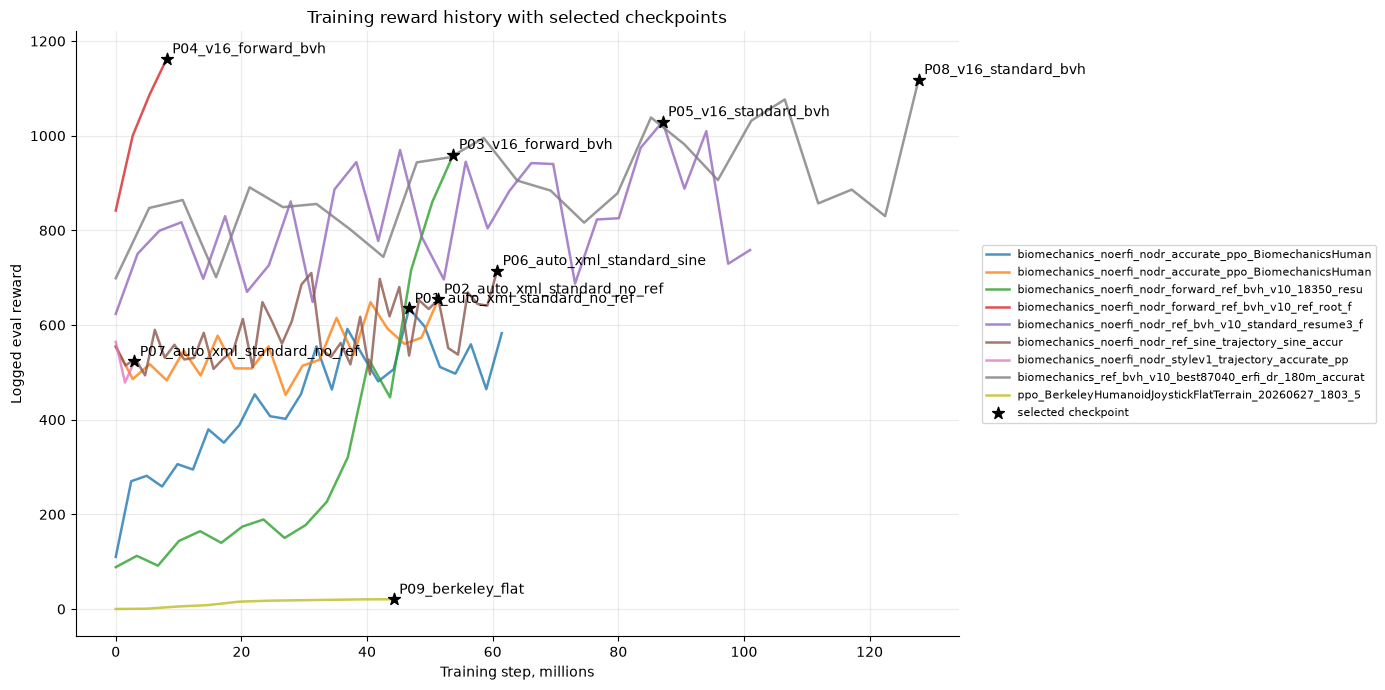

In [6]:
if training_history.empty or "reward" not in training_history:
    display(Markdown("Nema parsirane trening istorije sa `reward` kolonom."))
else:
    history_plot = training_history.copy()
    history_plot["step_m"] = history_plot["step"] / 1_000_000

    fig, ax = plt.subplots(figsize=(14, 7))
    for run_name, group in history_plot.groupby("run_name", sort=False):
        ax.plot(group["step_m"], group["reward"], linewidth=1.8, alpha=0.8, label=run_name[:55])

    best_points = selected_checkpoints.dropna(subset=["training_reward"]).copy()
    best_points["step_m"] = best_points["checkpoint_step"] / 1_000_000
    ax.scatter(
        best_points["step_m"],
        best_points["training_reward"],
        s=80,
        marker="*",
        color="black",
        label="selected checkpoint",
        zorder=5,
    )
    for _, row in best_points.iterrows():
        ax.annotate(row["policy_id"], (row["step_m"], row["training_reward"]), xytext=(4, 4), textcoords="offset points")

    ax.set_title("Training reward history with selected checkpoints")
    ax.set_xlabel("Training step, millions")
    ax.set_ylabel("Logged eval reward")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

<!-- NOTEBOOK_TOP3_TRAINING_REWARD -->
### Top 3 po logged training reward-u

| policy_id | policy_type | checkpoint_step | training_reward | command_profile | reference_gait |
| --- | --- | --- | --- | --- | --- |
| P04_v16_forward_bvh | biomechanics | 8110080 | 1162 | forward | bvh |
| P08_v16_standard_bvh | biomechanics | 127795200 | 1119 | standard | bvh |
| P05_v16_standard_bvh | biomechanics | 87040000 | 1030 | standard | bvh |


- Najveci logged reward ima `P04_v16_forward_bvh` na checkpointu 8110080.
- Ovaj grafikon je dobar za pracenje napretka unutar jednog run-a; reward skale izmedju razlicitih environment verzija ne treba citati kao jedini dokaz da je policy bolji.


In [7]:
if not training_history.empty and "reward" in training_history:
    best_logged = (
        training_history.sort_values("reward", ascending=False)
        .groupby("run_name", as_index=False)
        .head(1)
        .sort_values("reward", ascending=False)
    )
    display(best_logged[["run_name", "step", "reward"]].reset_index(drop=True))

,run_name,step,reward
0,biomechanics_noerfi_nodr_forward_ref_bvh_v10_ref_root_foot_gate_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_1736_8m_seed7_re...,8110080,1162.4832
1,biomechanics_ref_bvh_v10_best87040_erfi_dr_180m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_2136_180m_seed7_running,127795200,1118.5432
2,biomechanics_noerfi_nodr_ref_bvh_v10_standard_resume3_from_29286400_100m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_0018_10...,87040000,1029.5856
3,biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7...,53739520,960.2457
4,biomechanics_noerfi_nodr_ref_sine_trajectory_sine_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2321_60m_seed7_rew_714p9127_be...,60702720,714.9127
5,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_0006_50m_seed7_rew_654p7552_best_654p7552_s,51363840,654.7552
6,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260615_1300_70m_seed7_running,46694400,635.1440
7,biomechanics_noerfi_nodr_stylev1_trajectory_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2241_70m_seed7_running,0,564.6565
8,ppo_BerkeleyHumanoidJoystickFlatTerrain_20260627_1803_50m_seed7,44236800,20.6182


## 5. Pokreni ili ucitaj rollout analizu

Ova celija je glavna. Ako `analysis_outputs/policy_metrics.csv` vec postoji i `FORCE_RECOMPUTE = False`, ucitava postojece CSV-ove. Ako ne postoji, radi rollout za svaki izabrani checkpoint.

In [9]:
tables = wa.run_analysis(
    runs_dir=RUNS_DIR,
    output_dir=OUTPUT_DIR,
    scenarios=SCENARIOS,
    seeds=SEEDS,
    steps_per_scenario=STEPS_PER_SCENARIO,
    force=FORCE_RECOMPUTE,
)

for table_name, table in tables.items():
    print(f"{table_name:22s} rows={len(table):8d} cols={len(table.columns):4d}")

Loading cached analysis from c:\Users\aleks\Desktop\Aleksie kerefeke\master\RS projekat - RL politika ucenja joystick\mujoco-bipedal-joystick-walker\analysis_outputs
selected_checkpoints   rows=       9 cols=  12
training_history       rows=     175 cols=  26
rollout_steps          rows=   54000 cols= 469
episode_metrics        rows=     205 cols=  43
trial_metrics          rows=     108 cols=  25
policy_metrics         rows=      63 cols=  35
actuator_metrics       rows=    1620 cols=  11


In [10]:
selected = tables.get("selected_checkpoints", selected_checkpoints)
history = tables.get("training_history", training_history)
steps = tables["rollout_steps"]
episode_metrics = tables["episode_metrics"]
trial_metrics = tables["trial_metrics"]
policy_metrics = tables["policy_metrics"]
actuator_metrics = tables["actuator_metrics"]

expected_rows = len(selected) * len(SCENARIOS) * len(SEEDS) * STEPS_PER_SCENARIO
display(
    pd.DataFrame(
        [
            {"check": "expected rollout rows", "value": expected_rows},
            {"check": "actual rollout rows", "value": len(steps)},
            {"check": "policies", "value": steps["policy_id"].nunique()},
            {"check": "scenarios", "value": steps["scenario"].nunique()},
            {"check": "seeds", "value": steps["seed"].nunique()},
            {"check": "falls", "value": int(steps["done"].sum())},
        ]
    )
)

,check,value
0,expected rollout rows,54000
1,actual rollout rows,54000
2,policies,9
3,scenarios,6
4,seeds,2
5,falls,97


## 6. Pomocne funkcije za prikaz

In [11]:
def display_table(title: str, table: pd.DataFrame, rows: int = 20) -> None:
    """Display a titled table without truncating important context."""
    display(Markdown(f"### {title}"))
    display(table.head(rows))


def metric_matrix(
    table: pd.DataFrame,
    value: str,
    index: str = "policy_id",
    columns: str = "scenario",
    aggfunc: str = "mean",
) -> pd.DataFrame:
    """Create a policy-by-scenario matrix for heatmaps."""
    return table.pivot_table(index=index, columns=columns, values=value, aggfunc=aggfunc)


def plot_horizontal_bar(
    table: pd.DataFrame,
    x: str,
    y: str = "policy_id",
    title: str | None = None,
    color: str = "#2f6f9f",
) -> None:
    """Plot a sorted horizontal bar chart."""
    plot_data = table.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(plot_data))))
    ax.barh(plot_data[y], plot_data[x], color=color, alpha=0.9)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title or x)
    for value, label in zip(plot_data[x], plot_data[y], strict=False):
        if pd.notna(value):
            ax.text(value, label, f" {value:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    cmap: str = "viridis",
    fmt: str = ".2f",
) -> None:
    """Plot a compact annotated heatmap using only matplotlib."""
    matrix = matrix.copy()
    fig_width = max(8, 1.35 * len(matrix.columns))
    fig_height = max(4.5, 0.5 * len(matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(len(matrix.columns)), labels=matrix.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(matrix.index)), labels=matrix.index)
    ax.set_title(title)
    for row_index in range(len(matrix.index)):
        for column_index in range(len(matrix.columns)):
            value = matrix.iloc[row_index, column_index]
            label = "nan" if pd.isna(value) else format(value, fmt)
            ax.text(column_index, row_index, label, ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()


def label_scatter_points(ax: plt.Axes, table: pd.DataFrame, x: str, y: str, label: str = "policy_id") -> None:
    """Annotate scatter points with policy IDs."""
    for _, row in table.iterrows():
        ax.annotate(str(row[label]), (row[x], row[y]), xytext=(5, 4), textcoords="offset points", fontsize=8)


def compact_policy_name(policy_id: str) -> str:
    """Shorten policy IDs for dense chart labels."""
    return policy_id.replace("auto_xml_", "").replace("standard_", "std_")

## 7. Rang lista najboljih politika hoda

In [12]:
leaderboard = (
    policy_metrics.loc[policy_metrics["scenario"].eq("IN_DISTRIBUTION")]
    .sort_values("composite_score", ascending=False)
    .reset_index(drop=True)
)
leaderboard["rank"] = np.arange(1, len(leaderboard) + 1)

leaderboard_columns = [
    "rank",
    "policy_id",
    "policy_type",
    "checkpoint_step",
    "composite_score",
    "mean_first_fall_survival_fraction",
    "fall_rate_per_1000_steps",
    "tracking_rmse",
    "mean_torso_up",
    "mean_action_rate_norm",
    "mean_mechanical_power_abs",
]
display_table("In-distribution policy leaderboard", leaderboard[leaderboard_columns], rows=len(leaderboard))

### In-distribution policy leaderboard

,rank,policy_id,policy_type,checkpoint_step,composite_score,mean_first_fall_survival_fraction,fall_rate_per_1000_steps,tracking_rmse,mean_torso_up,mean_action_rate_norm,mean_mechanical_power_abs
0,1,P08_v16_standard_bvh,biomechanics,127795200,0.7490,1.0000,0.0000,0.1618,0.9416,42.0196,251.7894
1,2,P09_berkeley_flat,berkeley,44236800,0.6092,0.9502,1.3333,0.5778,0.9888,27.8262,55.0472
2,3,P04_v16_forward_bvh,biomechanics,8110080,0.6043,0.9307,0.3333,0.2604,0.9414,34.4703,212.6142
3,4,P05_v16_standard_bvh,biomechanics,87040000,0.5620,0.9028,0.8333,0.3229,0.9659,37.9780,229.5472
4,5,P03_v16_forward_bvh,biomechanics,53739520,0.5582,0.9567,0.6667,0.3697,0.9332,32.8065,207.1853
5,6,P06_auto_xml_standard_sine,biomechanics,60702720,0.5081,0.8460,1.0000,0.1741,0.9466,37.3925,190.4017
6,7,P02_auto_xml_standard_no_ref,biomechanics,51363840,0.3763,0.7805,1.3333,0.2079,0.9448,34.8924,190.3790
7,8,P07_auto_xml_standard_no_ref,biomechanics,2949120,0.3161,0.8113,1.3333,0.2704,0.9262,36.5922,200.1966
8,9,P01_auto_xml_standard_no_ref,biomechanics,46694400,0.2658,0.7972,1.3333,0.3249,0.9287,35.5949,192.3938


In [13]:
if not leaderboard.empty:
    winner = leaderboard.iloc[0]
    summary = f"""
### Automatski rezime

- Najbolji in-distribution policy: **{winner['policy_id']}**.
- Composite score: **{winner['composite_score']:.3f}**.
- Survival fraction do prvog pada: **{winner['mean_first_fall_survival_fraction']:.3f}**.
- Tracking RMSE: **{winner['tracking_rmse']:.3f}**.
- Mean torso up: **{winner['mean_torso_up']:.3f}**.
- Mean action rate norm: **{winner['mean_action_rate_norm']:.3f}**.
"""
    display(Markdown(summary))


### Automatski rezime

- Najbolji in-distribution policy: **P08_v16_standard_bvh**.
- Composite score: **0.749**.
- Survival fraction do prvog pada: **1.000**.
- Tracking RMSE: **0.162**.
- Mean torso up: **0.942**.
- Mean action rate norm: **42.020**.


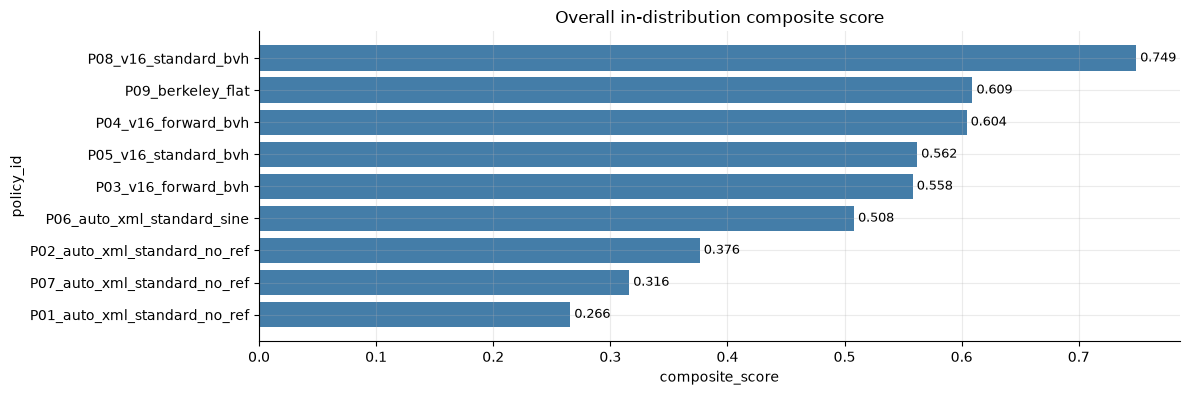

In [14]:
plot_horizontal_bar(
    leaderboard,
    x="composite_score",
    title="Overall in-distribution composite score",
    color="#2f6f9f",
)

<!-- NOTEBOOK_TOP3_COMPOSITE -->
### Top 3 po composite score-u

| rank | policy_id | policy_type | composite_score | mean_first_fall_survival_fraction | tracking_rmse | mean_torso_up | mean_action_rate_norm |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | P08_v16_standard_bvh | biomechanics | 0.7490 | 1.0000 | 0.1618 | 0.9416 | 42.0196 |
| 2 | P09_berkeley_flat | berkeley | 0.6092 | 0.9502 | 0.5778 | 0.9888 | 27.8262 |
| 3 | P04_v16_forward_bvh | biomechanics | 0.6043 | 0.9307 | 0.2604 | 0.9414 | 34.4703 |


- Najbolji ukupni rezultat ima `P08_v16_standard_bvh` jer balansira prezivljavanje, tracking, uspravnost i glatkocu akcija.
- Composite score je najkorisniji kao prva rang lista, a detaljni grafikoni ispod objasnjavaju zasto je neko dobar ili los.


Composite score je transparentna kombinacija iz `walking_analysis.py`: 40% survival, 30% tracking, 20% upright posture, 10% smoothness. Dobar policy treba da prezivi, prati komandu, ostane uspravan i ne pravi divlje akcije.

## 8. Scenario matrix: gde je politika stabilna, a gde gubi kvalitet

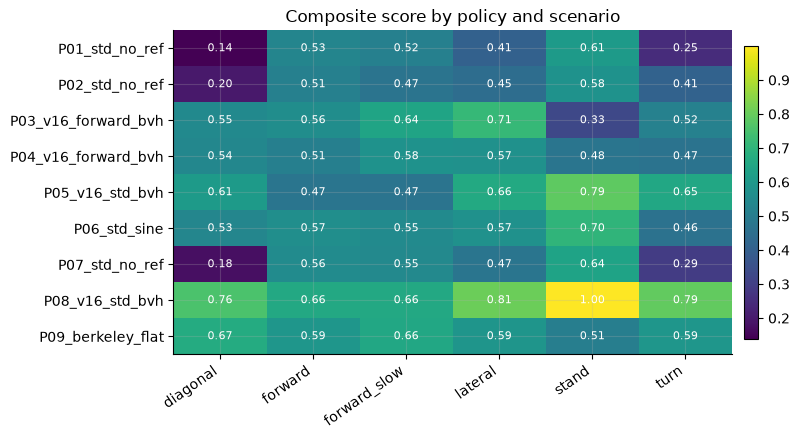

In [15]:
scenario_metrics = policy_metrics.loc[~policy_metrics["scenario"].eq("IN_DISTRIBUTION")].copy()
scenario_metrics["policy_label"] = scenario_metrics["policy_id"].map(compact_policy_name)

score_matrix = metric_matrix(scenario_metrics, value="composite_score", index="policy_label")
plot_heatmap(score_matrix, "Composite score by policy and scenario", cmap="viridis", fmt=".2f")

<!-- NOTEBOOK_TOP3_SCENARIO_SCORE -->
### Top 3 kroz sve scenarije

| policy_id | policy_type | mean_composite_score | worst_composite_score | mean_tracking_rmse | mean_fall_rate |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7785 | 0.6579 | 0.1470 | 0.0000 |
| P05_v16_standard_bvh | biomechanics | 0.6097 | 0.4698 | 0.2656 | 0.8333 |
| P09_berkeley_flat | berkeley | 0.6008 | 0.5082 | 0.5682 | 1.3333 |


- Najstabilniji prosek kroz eksplicitne scenarije ima `P08_v16_standard_bvh`.
- Heatmap pokazuje gde policy generalizuje: svetla polja su jaka, a tamna polja su scenariji u kojima policy gubi stabilnost ili slabije prati komandu.


In [16]:
scenario_leaders = (
    scenario_metrics.sort_values(["scenario", "composite_score"], ascending=[True, False])
    .groupby("scenario", as_index=False)
    .head(3)
    .loc[:, [
        "scenario",
        "policy_id",
        "policy_type",
        "composite_score",
        "tracking_rmse",
        "fall_rate_per_1000_steps",
        "mean_torso_up",
        "mean_action_rate_norm",
    ]]
)
display_table("Top 3 policies per scenario", scenario_leaders, rows=len(scenario_leaders))

### Top 3 policies per scenario

,scenario,policy_id,policy_type,composite_score,tracking_rmse,fall_rate_per_1000_steps,mean_torso_up,mean_action_rate_norm
9,diagonal,P08_v16_standard_bvh,biomechanics,0.7551,0.1985,0.0000,0.9305,51.0225
10,diagonal,P09_berkeley_flat,berkeley,0.6680,0.5004,1.0000,0.9904,26.9287
11,diagonal,P05_v16_standard_bvh,biomechanics,0.6096,0.2141,0.0000,0.9548,49.4440
18,forward,P08_v16_standard_bvh,biomechanics,0.6579,0.1611,0.0000,0.9326,49.4697
19,forward,P09_berkeley_flat,berkeley,0.5920,0.4262,1.0000,0.9909,27.2942
20,forward,P06_auto_xml_standard_sine,biomechanics,0.5658,0.0794,0.0000,0.9794,59.1138
27,forward_slow,P08_v16_standard_bvh,biomechanics,0.6586,0.1328,0.0000,0.9252,49.5313
28,forward_slow,P09_berkeley_flat,berkeley,0.6569,0.5493,1.0000,0.9909,28.0770
29,forward_slow,P03_v16_forward_bvh,biomechanics,0.6422,0.1995,0.0000,0.9316,32.5561
36,lateral,P08_v16_standard_bvh,biomechanics,0.8074,0.1486,0.0000,0.9446,49.8575


In [17]:
overall_scenario_score = (
    scenario_metrics.groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_composite_score=("composite_score", "mean"),
        worst_composite_score=("composite_score", "min"),
        mean_tracking_rmse=("tracking_rmse", "mean"),
        mean_fall_rate=("fall_rate_per_1000_steps", "mean"),
        mean_survival=("mean_first_fall_survival_fraction", "mean"),
        mean_power=("mean_mechanical_power_abs", "mean"),
    )
    .sort_values(["mean_composite_score", "worst_composite_score"], ascending=False)
    .reset_index(drop=True)
)
overall_scenario_score["rank"] = np.arange(1, len(overall_scenario_score) + 1)
display_table("Mean score across all explicit scenarios", overall_scenario_score, rows=len(overall_scenario_score))

### Mean score across all explicit scenarios

,policy_id,policy_type,mean_composite_score,worst_composite_score,mean_tracking_rmse,mean_fall_rate,mean_survival,mean_power,rank
0,P08_v16_standard_bvh,biomechanics,0.7785,0.6579,0.1470,0.0000,1.0000,251.7894,1
1,P05_v16_standard_bvh,biomechanics,0.6097,0.4698,0.2656,0.8333,0.9028,229.5472,2
2,P09_berkeley_flat,berkeley,0.6008,0.5082,0.5682,1.3333,0.9502,55.0472,3
3,P06_auto_xml_standard_sine,biomechanics,0.5658,0.4644,0.1220,1.0000,0.8460,190.4017,4
4,P03_v16_forward_bvh,biomechanics,0.5516,0.3280,0.4494,4.5000,0.9567,216.8129,5
5,P04_v16_forward_bvh,biomechanics,0.5238,0.4666,0.4138,4.5000,0.9307,212.4978,6
6,P07_auto_xml_standard_no_ref,biomechanics,0.4467,0.1756,0.1910,1.3333,0.8113,200.1966,7
7,P02_auto_xml_standard_no_ref,biomechanics,0.4369,0.1996,0.1562,1.3333,0.7805,190.3790,8
8,P01_auto_xml_standard_no_ref,biomechanics,0.4083,0.1399,0.2247,1.3333,0.7972,192.3938,9


## 9. Survival i padovi

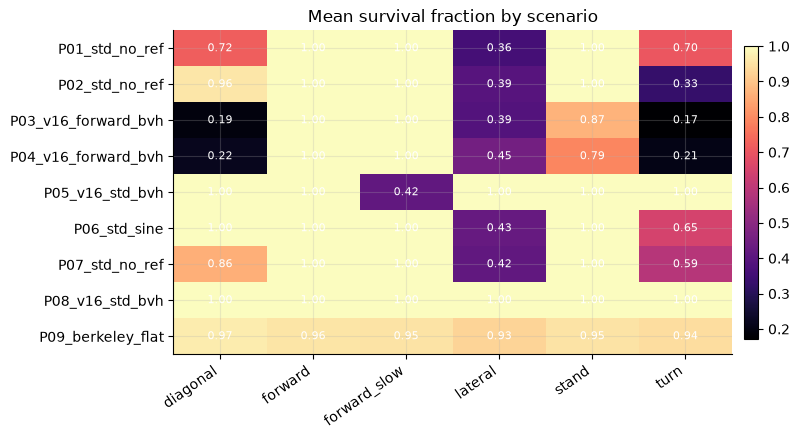

In [18]:
survival_by_scenario = (
    trial_metrics.groupby(["policy_id", "scenario"], as_index=False)
    .agg(
        mean_survival_fraction=("survival_fraction", "mean"),
        falls=("falls", "sum"),
        first_fall_time_s=("first_fall_time_s", "mean"),
    )
)
survival_by_scenario["policy_label"] = survival_by_scenario["policy_id"].map(compact_policy_name)

survival_matrix = metric_matrix(survival_by_scenario, value="mean_survival_fraction", index="policy_label")
plot_heatmap(survival_matrix, "Mean survival fraction by scenario", cmap="magma", fmt=".2f")

<!-- NOTEBOOK_TOP3_SURVIVAL -->
### Top 3 po survival fraction-u

| policy_id | policy_type | mean_survival_fraction | total_falls | min_first_fall_time_s | mean_min_torso_up |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 1.0000 | 0.0000 | 10.0000 | 0.8564 |
| P09_berkeley_flat | berkeley | 0.9502 | 8.0000 | 9.0600 | 0.2906 |
| P05_v16_standard_bvh | biomechanics | 0.9028 | 5.0000 | 2.6800 | 0.8883 |


- Najbolji survival ima `P08_v16_standard_bvh`.
- Survival fraction blizu 1 znaci da policy uglavnom izgura ceo rollout bez ranog pada.


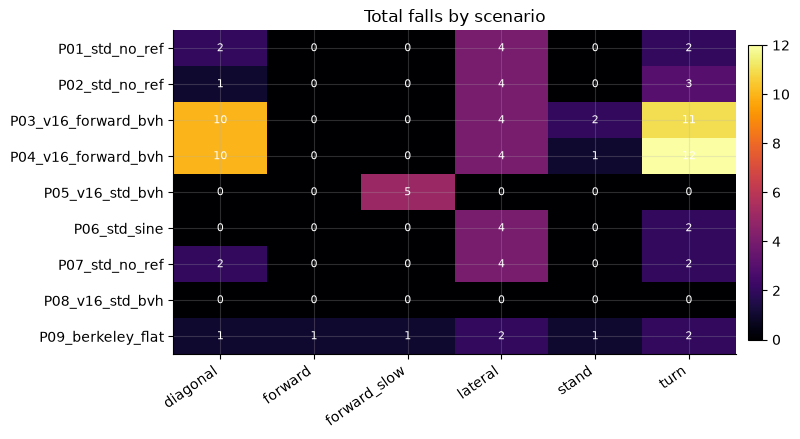

In [19]:
fall_matrix = metric_matrix(survival_by_scenario, value="falls", index="policy_label", aggfunc="sum")
plot_heatmap(fall_matrix, "Total falls by scenario", cmap="inferno", fmt=".0f")

<!-- NOTEBOOK_TOP3_LEAST_FALLS -->
### Top 3 sa najmanje padova

| policy_id | policy_type | total_falls | mean_survival_fraction | min_first_fall_time_s | mean_min_torso_up |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.0000 | 1.0000 | 10.0000 | 0.8564 |
| P05_v16_standard_bvh | biomechanics | 5.0000 | 0.9028 | 2.6800 | 0.8883 |
| P09_berkeley_flat | berkeley | 8.0000 | 0.9502 | 9.0600 | 0.2906 |


- Najmanje padova ima `P08_v16_standard_bvh`.
- Ovaj pregled je strozi od reward-a: ako policy izgleda dobro po reward-u ali ima mnogo padova, nije robustan za demonstraciju hodanja.


In [20]:
fall_summary = (
    trial_metrics.groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        total_falls=("falls", "sum"),
        mean_survival_fraction=("survival_fraction", "mean"),
        min_first_fall_time_s=("first_fall_time_s", "min"),
        mean_min_root_height=("min_root_height", "mean"),
        mean_min_torso_up=("min_torso_up", "mean"),
    )
    .sort_values(["total_falls", "mean_survival_fraction"], ascending=[True, False])
)
display_table("Fall robustness summary", fall_summary, rows=len(fall_summary))

### Fall robustness summary

,policy_id,policy_type,total_falls,mean_survival_fraction,min_first_fall_time_s,mean_min_root_height,mean_min_torso_up
7,P08_v16_standard_bvh,biomechanics,0.0000,1.0000,10.0000,1.3938,0.8564
4,P05_v16_standard_bvh,biomechanics,5.0000,0.9028,2.6800,1.3266,0.8883
5,P06_auto_xml_standard_sine,biomechanics,6.0000,0.8460,3.8000,1.2326,0.8394
8,P09_berkeley_flat,berkeley,8.0000,0.9502,9.0600,0.2309,0.2906
6,P07_auto_xml_standard_no_ref,biomechanics,8.0000,0.8113,3.8600,1.1607,0.7928
0,P01_auto_xml_standard_no_ref,biomechanics,8.0000,0.7972,3.5400,1.1566,0.7888
1,P02_auto_xml_standard_no_ref,biomechanics,8.0000,0.7805,3.0800,1.1999,0.8220
3,P04_v16_forward_bvh,biomechanics,27.0000,0.6115,1.5400,1.0963,0.7272
2,P03_v16_forward_bvh,biomechanics,27.0000,0.6042,1.4800,1.0561,0.7227


## 10. Command tracking

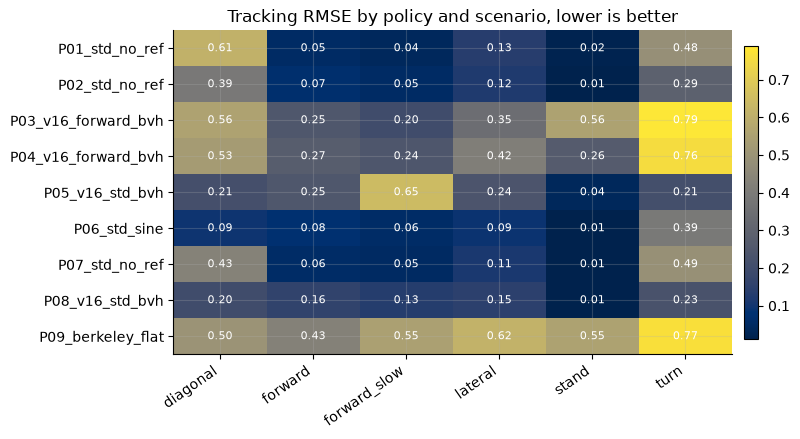

In [21]:
tracking_matrix = metric_matrix(scenario_metrics.assign(policy_label=scenario_metrics["policy_id"].map(compact_policy_name)), value="tracking_rmse", index="policy_label")
plot_heatmap(tracking_matrix, "Tracking RMSE by policy and scenario, lower is better", cmap="cividis", fmt=".2f")

<!-- NOTEBOOK_TOP3_TRACKING -->
### Top 3 po command tracking-u

| policy_id | policy_type | mean_tracking_rmse | mean_command_failure_rate | mean_horizontal_speed | total_falls |
| --- | --- | --- | --- | --- | --- |
| P06_auto_xml_standard_sine | biomechanics | 0.1179 | 0.0208 | 0.1987 | 6.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.1461 | 0.0487 | 0.2141 | 8.0000 |
| P08_v16_standard_bvh | biomechanics | 0.1467 | 0.1142 | 0.2110 | 0.0000 |


- Najbolji prosecni tracking ima `P06_auto_xml_standard_sine`.
- Nizi RMSE znaci da policy bolje prati zadatu joystick komandu; ovo je posebno vazno za forward/lateral/turn scenarije.


In [22]:
tracking_details = (
    trial_metrics.groupby(["policy_id", "scenario"], as_index=False)
    .agg(
        tracking_rmse=("tracking_rmse", "mean"),
        command_failure_rate=("command_failure_rate", "mean"),
        mean_horizontal_speed=("mean_horizontal_speed", "mean"),
    )
    .sort_values(["scenario", "tracking_rmse"])
)
display_table("Tracking details", tracking_details, rows=60)

### Tracking details

,policy_id,scenario,tracking_rmse,command_failure_rate,mean_horizontal_speed
30,P06_auto_xml_standard_sine,diagonal,0.0948,0.0070,0.3218
42,P08_v16_standard_bvh,diagonal,0.1983,0.1880,0.3105
24,P05_v16_standard_bvh,diagonal,0.2140,0.1960,0.3139
6,P02_auto_xml_standard_no_ref,diagonal,0.3319,0.1130,0.3470
36,P07_auto_xml_standard_no_ref,diagonal,0.4296,0.1560,0.4217
48,P09_berkeley_flat,diagonal,0.4921,0.4610,0.3455
18,P04_v16_forward_bvh,diagonal,0.5293,0.9960,0.4954
12,P03_v16_forward_bvh,diagonal,0.5572,0.9880,0.5137
0,P01_auto_xml_standard_no_ref,diagonal,0.6118,0.1690,0.4240
1,P01_auto_xml_standard_no_ref,forward,0.0543,0.0100,0.3338


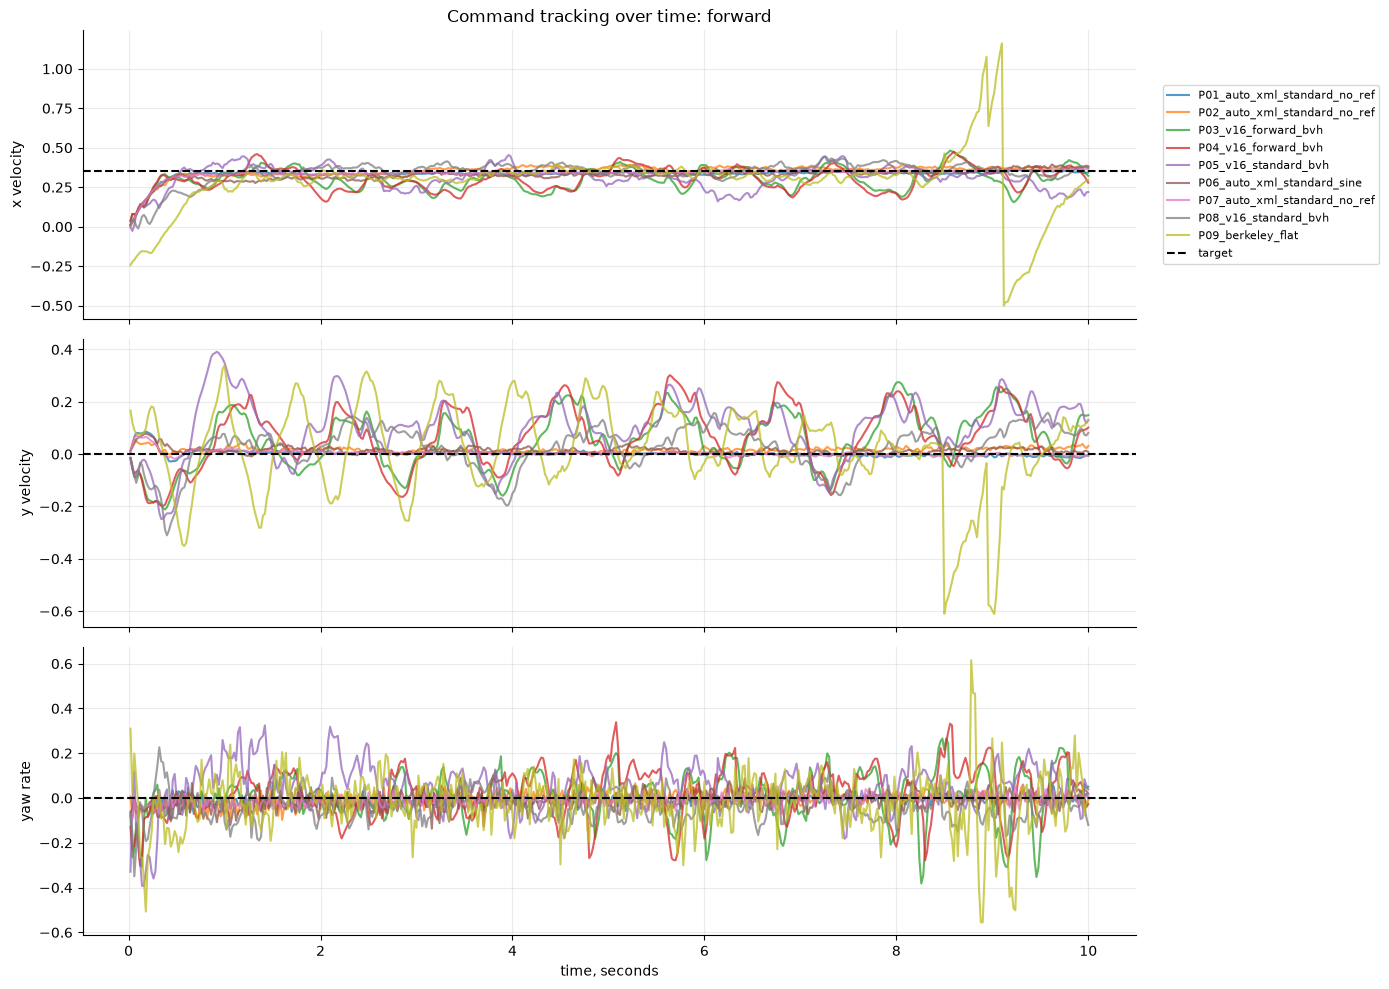

In [23]:
selected_scenario = "forward"
tracking_time = (
    steps.loc[steps["scenario"].eq(selected_scenario)]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(
        command_x=("command_x", "mean"),
        measured_command_x=("measured_command_x", "mean"),
        command_y=("command_y", "mean"),
        measured_command_y=("measured_command_y", "mean"),
        command_yaw=("command_yaw", "mean"),
        measured_command_yaw=("measured_command_yaw", "mean"),
        time_s=("time_s", "mean"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for policy_id, group in tracking_time.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["measured_command_x"], alpha=0.75, label=policy_id)
    axes[1].plot(group["time_s"], group["measured_command_y"], alpha=0.75)
    axes[2].plot(group["time_s"], group["measured_command_yaw"], alpha=0.75)

if not tracking_time.empty:
    axes[0].axhline(tracking_time["command_x"].iloc[0], color="black", linestyle="--", linewidth=1.5, label="target")
    axes[1].axhline(tracking_time["command_y"].iloc[0], color="black", linestyle="--", linewidth=1.5)
    axes[2].axhline(tracking_time["command_yaw"].iloc[0], color="black", linestyle="--", linewidth=1.5)

axes[0].set_title(f"Command tracking over time: {selected_scenario}")
axes[0].set_ylabel("x velocity")
axes[1].set_ylabel("y velocity")
axes[2].set_ylabel("yaw rate")
axes[2].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_FORWARD_TRACKING_LINE -->
### Top 3 za forward line chart

| policy_id | policy_type | tracking_rmse | command_failure_rate | mean_horizontal_speed | falls |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.0543 | 0.0100 | 0.3338 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.0567 | 0.0100 | 0.3397 | 0.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.0681 | 0.0110 | 0.3529 | 0.0000 |


- Na forward komandi najcistije prati `P01_auto_xml_standard_no_ref`.
- Line chart je namerno detaljan; ova tabela izvlaci tri politike koje u tom scenariju imaju najmanji tracking error.


<!-- FILTERED_TOP4_COMMAND_TRACKING_NOTES -->
### Filtrirani command tracking: samo top 4

| policy_id | policy_type | tracking_rmse | command_failure_rate | mean_horizontal_speed | falls |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.0543 | 0.0100 | 0.3338 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.0567 | 0.0100 | 0.3397 | 0.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.0681 | 0.0110 | 0.3529 | 0.0000 |
| P06_auto_xml_standard_sine | biomechanics | 0.0793 | 0.0100 | 0.3303 | 0.0000 |


- Prikaz je ogranicen na top 4 politike po najmanjem tracking RMSE-u na `forward` scenariju.
- Ovo je verzija grafikona koju treba gledati za prezentaciju; ciljna komanda je crna isprekidana linija.


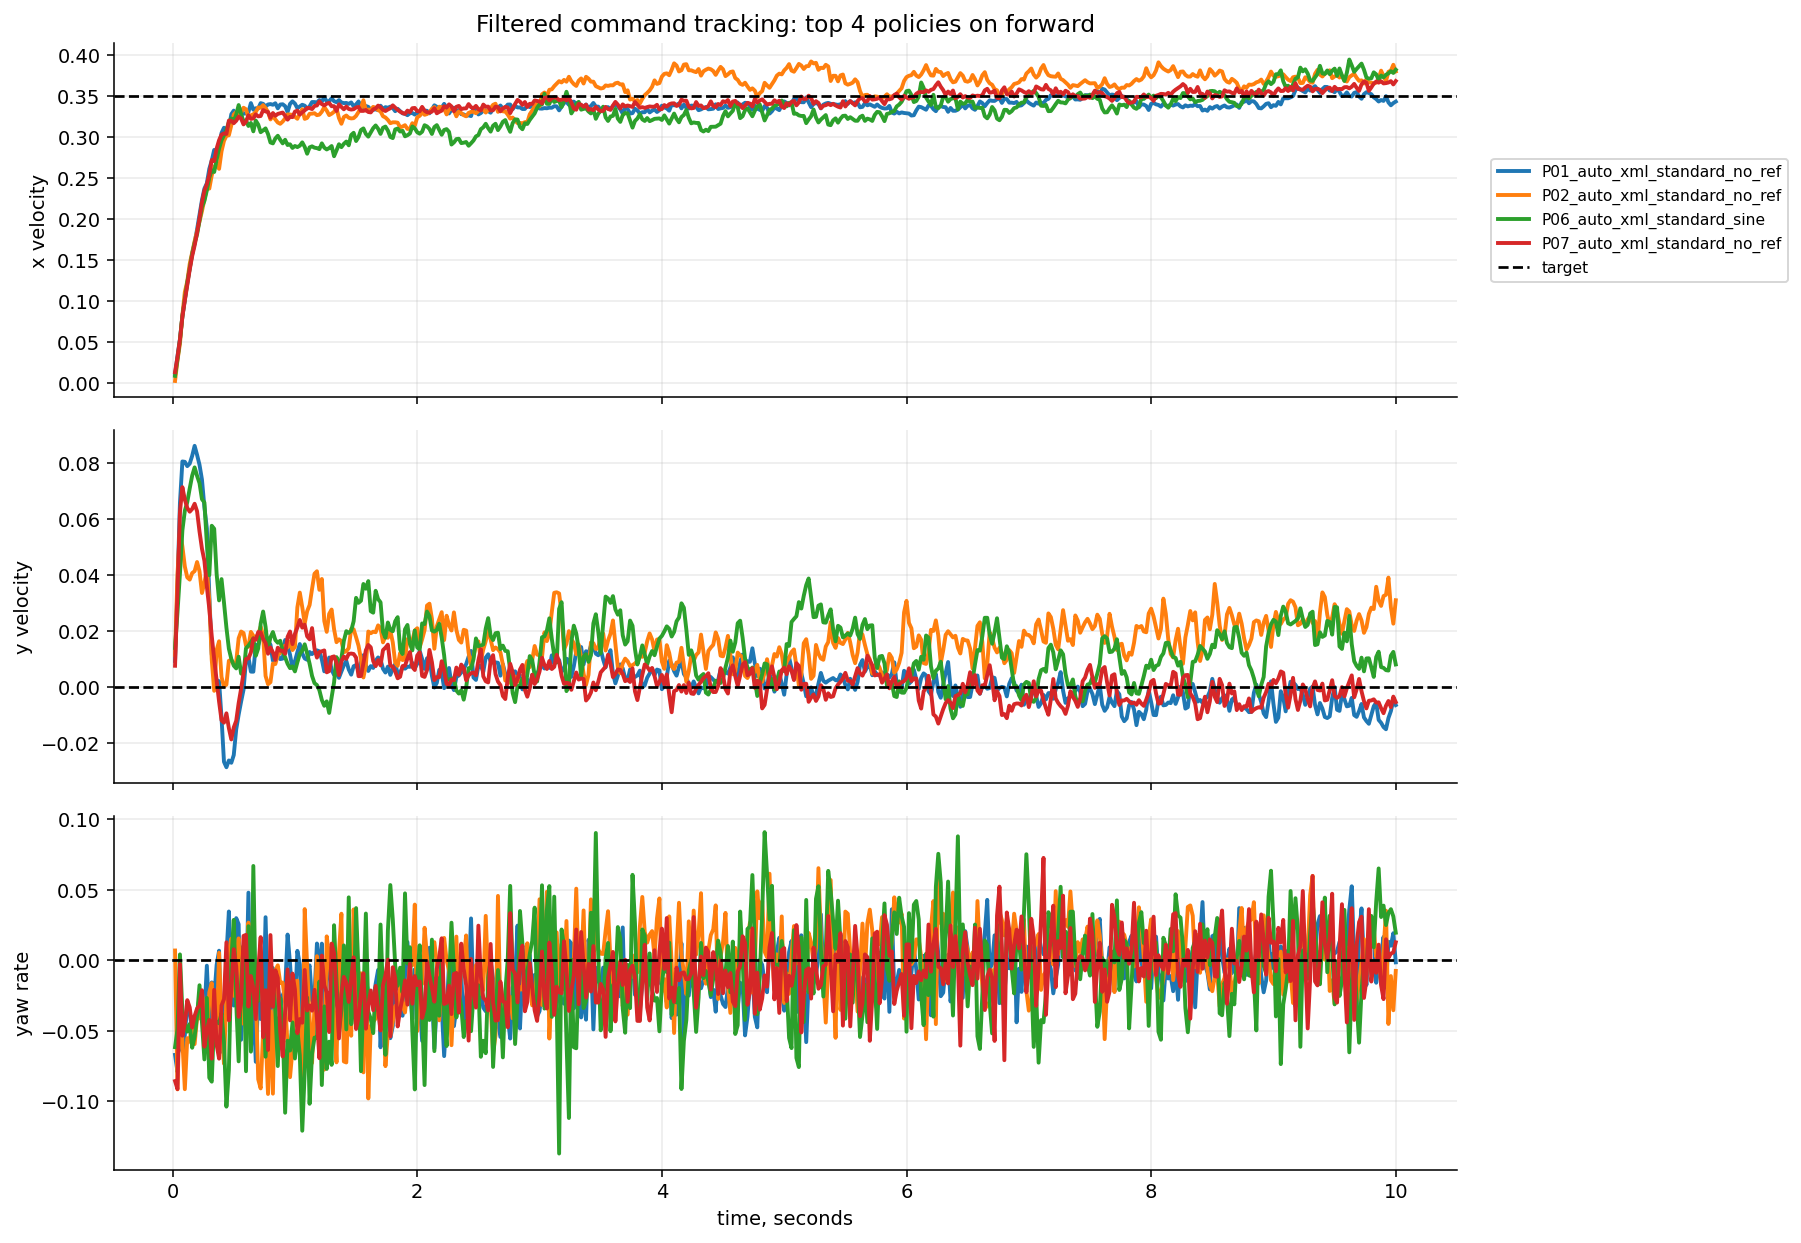

In [34]:
# Filtered command tracking: top 4 policies for the selected scenario.
filtered_scenario = "forward"
filtered_tracking_top4 = (
    trial_metrics.loc[trial_metrics["scenario"].eq(filtered_scenario)]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        tracking_rmse=("tracking_rmse", "mean"),
        command_failure_rate=("command_failure_rate", "mean"),
        mean_horizontal_speed=("mean_horizontal_speed", "mean"),
        falls=("falls", "sum"),
    )
    .sort_values(["tracking_rmse", "command_failure_rate", "falls"])
    .head(4)
)
filtered_policies = filtered_tracking_top4["policy_id"].tolist()
display(filtered_tracking_top4)

filtered_tracking_time = (
    steps.loc[
        steps["scenario"].eq(filtered_scenario)
        & steps["policy_id"].isin(filtered_policies)
    ]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(
        command_x=("command_x", "mean"),
        measured_command_x=("measured_command_x", "mean"),
        command_y=("command_y", "mean"),
        measured_command_y=("measured_command_y", "mean"),
        command_yaw=("command_yaw", "mean"),
        measured_command_yaw=("measured_command_yaw", "mean"),
        time_s=("time_s", "mean"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for policy_id, group in filtered_tracking_time.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["measured_command_x"], linewidth=2.0, label=policy_id)
    axes[1].plot(group["time_s"], group["measured_command_y"], linewidth=2.0, label=policy_id)
    axes[2].plot(group["time_s"], group["measured_command_yaw"], linewidth=2.0, label=policy_id)
if not filtered_tracking_time.empty:
    axes[0].axhline(filtered_tracking_time["command_x"].iloc[0], color="black", linestyle="--", linewidth=1.4, label="target")
    axes[1].axhline(filtered_tracking_time["command_y"].iloc[0], color="black", linestyle="--", linewidth=1.4)
    axes[2].axhline(filtered_tracking_time["command_yaw"].iloc[0], color="black", linestyle="--", linewidth=1.4)
axes[0].set_title(f"Filtered command tracking: top {len(filtered_policies)} policies on {filtered_scenario}")
axes[0].set_ylabel("x velocity")
axes[1].set_ylabel("y velocity")
axes[2].set_ylabel("yaw rate")
axes[2].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 11. Posture, smoothness i energy trade-off

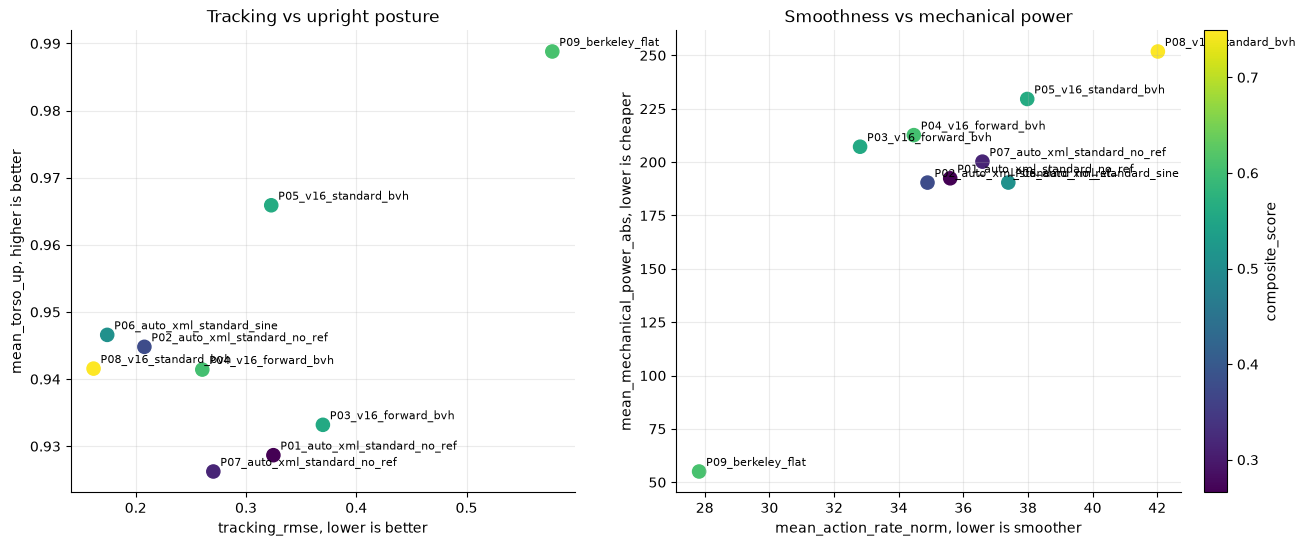

In [24]:
tradeoff = leaderboard.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(tradeoff["tracking_rmse"], tradeoff["mean_torso_up"], s=90, c=tradeoff["composite_score"], cmap="viridis")
label_scatter_points(axes[0], tradeoff, "tracking_rmse", "mean_torso_up")
axes[0].set_title("Tracking vs upright posture")
axes[0].set_xlabel("tracking_rmse, lower is better")
axes[0].set_ylabel("mean_torso_up, higher is better")

scatter = axes[1].scatter(
    tradeoff["mean_action_rate_norm"],
    tradeoff["mean_mechanical_power_abs"],
    s=90,
    c=tradeoff["composite_score"],
    cmap="viridis",
)
label_scatter_points(axes[1], tradeoff, "mean_action_rate_norm", "mean_mechanical_power_abs")
axes[1].set_title("Smoothness vs mechanical power")
axes[1].set_xlabel("mean_action_rate_norm, lower is smoother")
axes[1].set_ylabel("mean_mechanical_power_abs, lower is cheaper")

fig.colorbar(scatter, ax=axes, fraction=0.025, pad=0.02, label="composite_score")
plt.show()

<!-- NOTEBOOK_TOP3_TRADEOFF -->
### Top 3 balans tracking/stability/smoothness

| policy_id | policy_type | composite_score | tracking_rmse | mean_torso_up | mean_action_rate_norm | mean_mechanical_power_abs |
| --- | --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7490 | 0.1618 | 0.9416 | 42.0196 | 251.7894 |
| P09_berkeley_flat | berkeley | 0.6092 | 0.5778 | 0.9888 | 27.8262 | 55.0472 |
| P04_v16_forward_bvh | biomechanics | 0.6043 | 0.2604 | 0.9414 | 34.4703 | 212.6142 |


- Najbolji balans ima `P08_v16_standard_bvh`.
- Na scatter grafiku idealno je ici ka dobrom tracking-u i visokom torso_up, uz sto manji action_rate i manju potrosnju snage.


In [25]:
diagnostic_columns = [
    "policy_id",
    "scenario",
    "mean_root_height",
    "min_root_height",
    "mean_torso_up",
    "min_torso_up",
    "mean_tilt_angle_rad",
    "mean_action_norm",
    "mean_action_rate_norm",
    "mean_action_saturation_rate",
    "mean_mechanical_power_abs",
    "mean_foot_slip_speed",
]
display_table(
    "Posture and smoothness diagnostics by scenario",
    scenario_metrics[diagnostic_columns].sort_values(["scenario", "mean_torso_up"], ascending=[True, False]),
    rows=80,
)

### Posture and smoothness diagnostics by scenario

,policy_id,scenario,mean_root_height,min_root_height,mean_torso_up,min_torso_up,mean_tilt_angle_rad,mean_action_norm,mean_action_rate_norm,mean_action_saturation_rate,mean_mechanical_power_abs,mean_foot_slip_speed
10,P09_berkeley_flat,diagonal,0.5280,0.2051,0.9904,-0.0706,0.0692,1.5593,26.9287,0.0174,58.7791,0.0000
11,P05_v16_standard_bvh,diagonal,1.4727,1.4268,0.9548,0.8912,0.2838,2.2265,49.4440,0.0646,318.5932,0.2313
13,P04_v16_forward_bvh,diagonal,1.4161,0.8568,0.9310,0.8049,0.3439,2.1941,25.3716,0.0233,236.6860,0.4822
9,P08_v16_standard_bvh,diagonal,1.4585,1.3846,0.9305,0.8337,0.3505,2.1709,51.0225,0.0422,323.6486,0.2094
14,P06_auto_xml_standard_sine,diagonal,1.4350,1.3557,0.9238,0.8086,0.3685,2.0389,48.5604,0.0068,307.1972,0.7801
12,P03_v16_forward_bvh,diagonal,1.4110,0.8590,0.9233,0.7574,0.3638,2.1887,27.8152,0.0149,269.4412,0.5348
17,P01_auto_xml_standard_no_ref,diagonal,1.4014,0.8963,0.8988,0.6133,0.4164,1.9988,40.9608,0.0039,309.2538,0.8209
15,P02_auto_xml_standard_no_ref,diagonal,1.4124,0.9047,0.8956,0.4789,0.4206,2.1586,49.6080,0.0181,339.3433,0.8662
16,P07_auto_xml_standard_no_ref,diagonal,1.3886,0.8799,0.8491,0.3173,0.4987,2.0888,47.5730,0.0106,363.5498,0.9451
23,P01_auto_xml_standard_no_ref,forward,1.4809,1.4640,0.9963,0.9885,0.0769,1.7478,66.9453,0.0003,253.5126,0.7786


## 12. Trajektorije kroz prostor

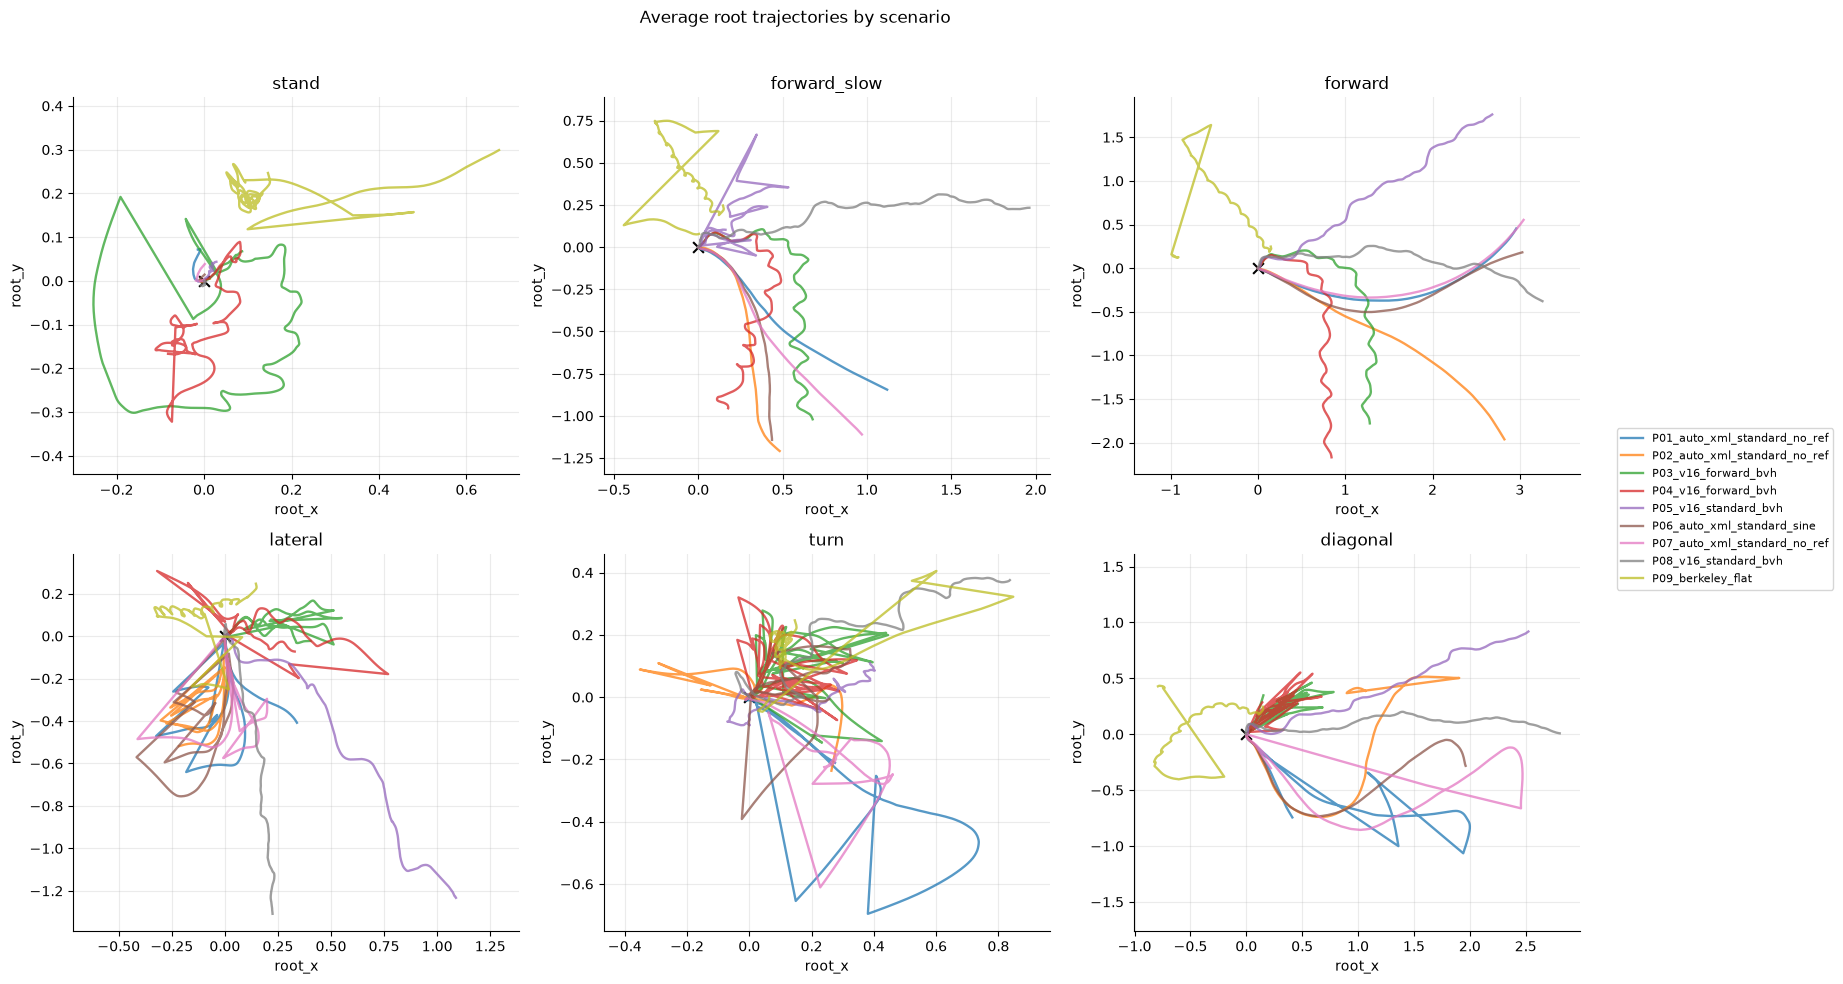

In [26]:
trajectory_summary = (
    steps.groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(root_x=("root_x", "mean"), root_y=("root_y", "mean"), root_z=("root_z", "mean"), done=("done", "mean"))
)

plot_scenarios = [name for name in scenario_names if name in trajectory_summary["scenario"].unique()]
cols = 3
rows = int(np.ceil(len(plot_scenarios) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4.8 * rows), squeeze=False)

for ax, scenario_name in zip(axes.ravel(), plot_scenarios, strict=False):
    subset = trajectory_summary.loc[trajectory_summary["scenario"].eq(scenario_name)]
    for policy_id, group in subset.groupby("policy_id", sort=False):
        ax.plot(group["root_x"], group["root_y"], alpha=0.75, linewidth=1.7, label=policy_id)
    ax.scatter([0], [0], marker="x", color="black", s=60)
    ax.set_title(scenario_name)
    ax.set_xlabel("root_x")
    ax.set_ylabel("root_y")
    ax.axis("equal")

for ax in axes.ravel()[len(plot_scenarios):]:
    ax.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.suptitle("Average root trajectories by scenario", y=1.02)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_TRAJECTORY -->
### Top 3 po regularnosti trajektorije

| policy_id | policy_type | mean_trajectory_straightness | mean_displacement_2d | mean_path_length_2d | mean_tracking_rmse |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.8169 | 1.1355 | 1.3894 | 0.2023 |
| P03_v16_forward_bvh | biomechanics | 0.7727 | 0.6865 | 1.0156 | 0.5327 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.7543 | 1.0405 | 1.3672 | 0.1760 |


- Najregularniju prosecniju trajektoriju ima `P01_auto_xml_standard_no_ref`.
- Ovo filtrira gusto nacrtane putanje; visoka straightness vrednost znaci da se policy manje tetura za isti predjeni put.


<!-- FILTERED_TOP4_ROOT_TRAJECTORIES_NOTES -->
### Filtrirane root trajektorije: samo top 4

| policy_id | policy_type | mean_composite_score | worst_composite_score | mean_tracking_rmse | mean_fall_rate |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7785 | 0.6579 | 0.1470 | 0.0000 |
| P05_v16_standard_bvh | biomechanics | 0.6097 | 0.4698 | 0.2656 | 0.8333 |
| P09_berkeley_flat | berkeley | 0.6008 | 0.5082 | 0.5682 | 1.3333 |
| P06_auto_xml_standard_sine | biomechanics | 0.5658 | 0.4644 | 0.1220 | 1.0000 |


- Prikaz je ogranicen na top 4 politike po prosecnom composite score-u kroz eksplicitne scenarije.
- Ova verzija je mnogo citljivija od punog grafikona i bolje pokazuje ko ide pravo, ko skrece i ko se tetura.


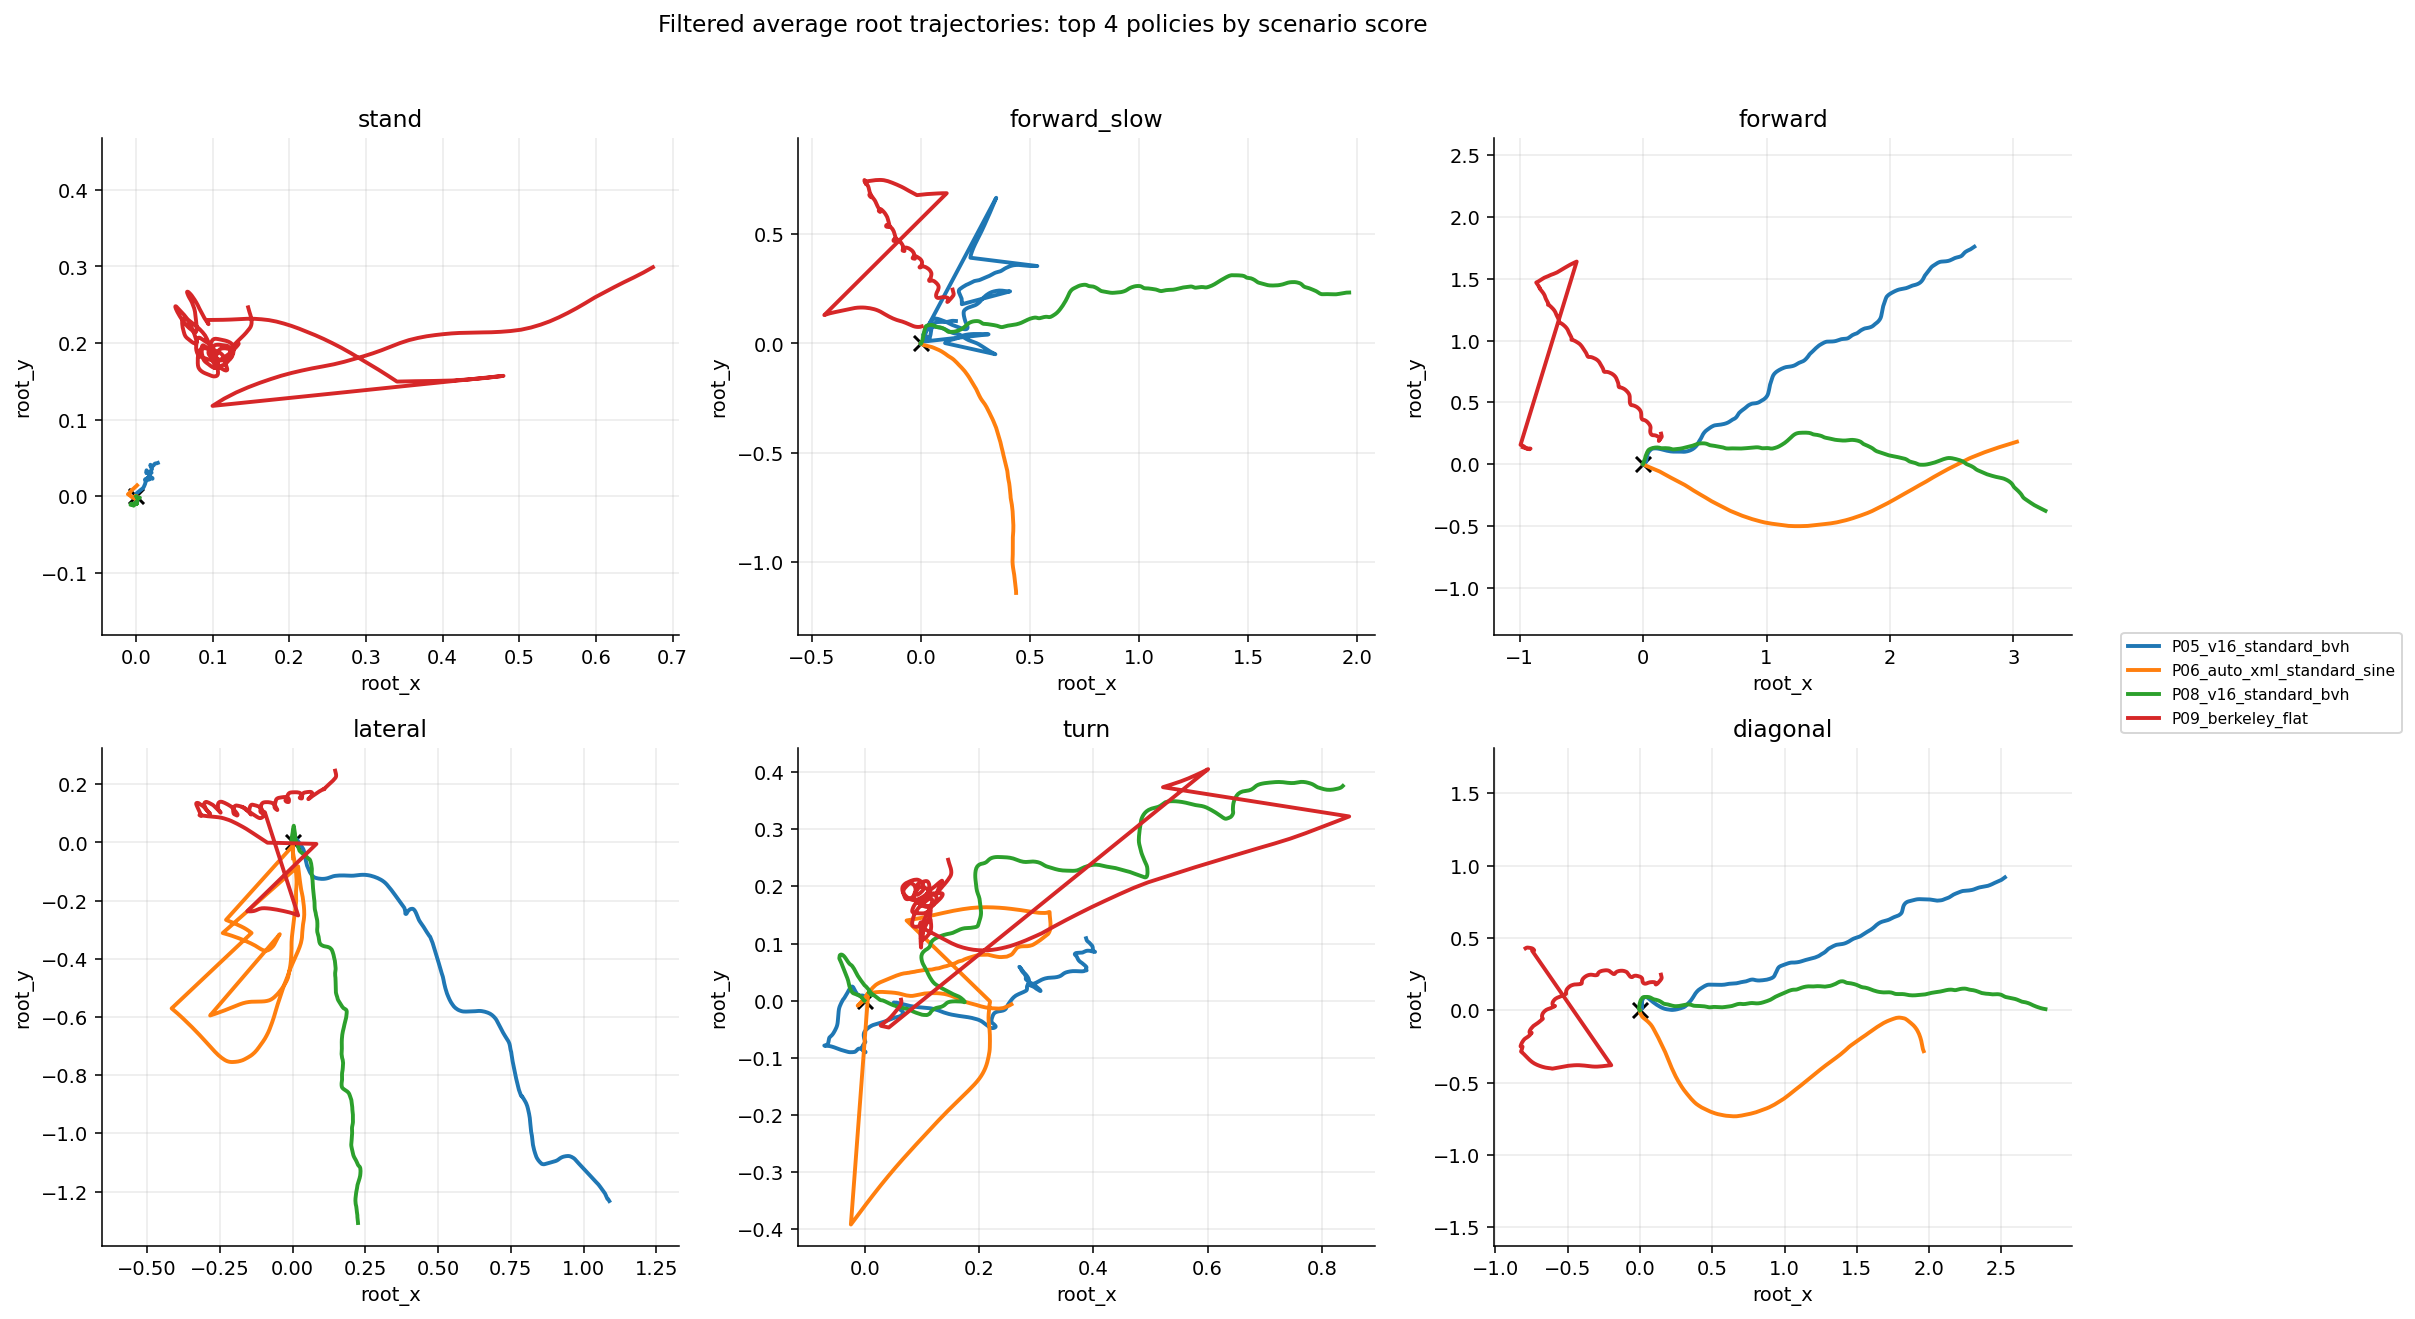

In [35]:
# Filtered root trajectories: top 4 policies by mean scenario composite score.
trajectory_top4 = (
    policy_metrics.loc[~policy_metrics["scenario"].eq("IN_DISTRIBUTION")]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_composite_score=("composite_score", "mean"),
        worst_composite_score=("composite_score", "min"),
        mean_tracking_rmse=("tracking_rmse", "mean"),
        mean_fall_rate=("fall_rate_per_1000_steps", "mean"),
    )
    .sort_values(["mean_composite_score", "worst_composite_score"], ascending=[False, False])
    .head(4)
)
filtered_policies = trajectory_top4["policy_id"].tolist()
display(trajectory_top4)

filtered_trajectory_summary = (
    steps.loc[steps["policy_id"].isin(filtered_policies)]
    .groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(root_x=("root_x", "mean"), root_y=("root_y", "mean"))
)
plot_scenarios = [name for name in scenario_names if name in filtered_trajectory_summary["scenario"].unique()]
cols = 3
rows = int(np.ceil(len(plot_scenarios) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 4.6 * rows), squeeze=False)
for ax, scenario_name in zip(axes.ravel(), plot_scenarios, strict=False):
    subset = filtered_trajectory_summary.loc[filtered_trajectory_summary["scenario"].eq(scenario_name)]
    for policy_id, group in subset.groupby("policy_id", sort=False):
        ax.plot(group["root_x"], group["root_y"], linewidth=2.0, label=policy_id)
    ax.scatter([0], [0], marker="x", color="black", s=60)
    ax.set_title(scenario_name)
    ax.set_xlabel("root_x")
    ax.set_ylabel("root_y")
    ax.axis("equal")
for ax in axes.ravel()[len(plot_scenarios):]:
    ax.axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.suptitle(f"Filtered average root trajectories: top {len(filtered_policies)} policies by scenario score", y=1.02)
plt.tight_layout()
plt.show()


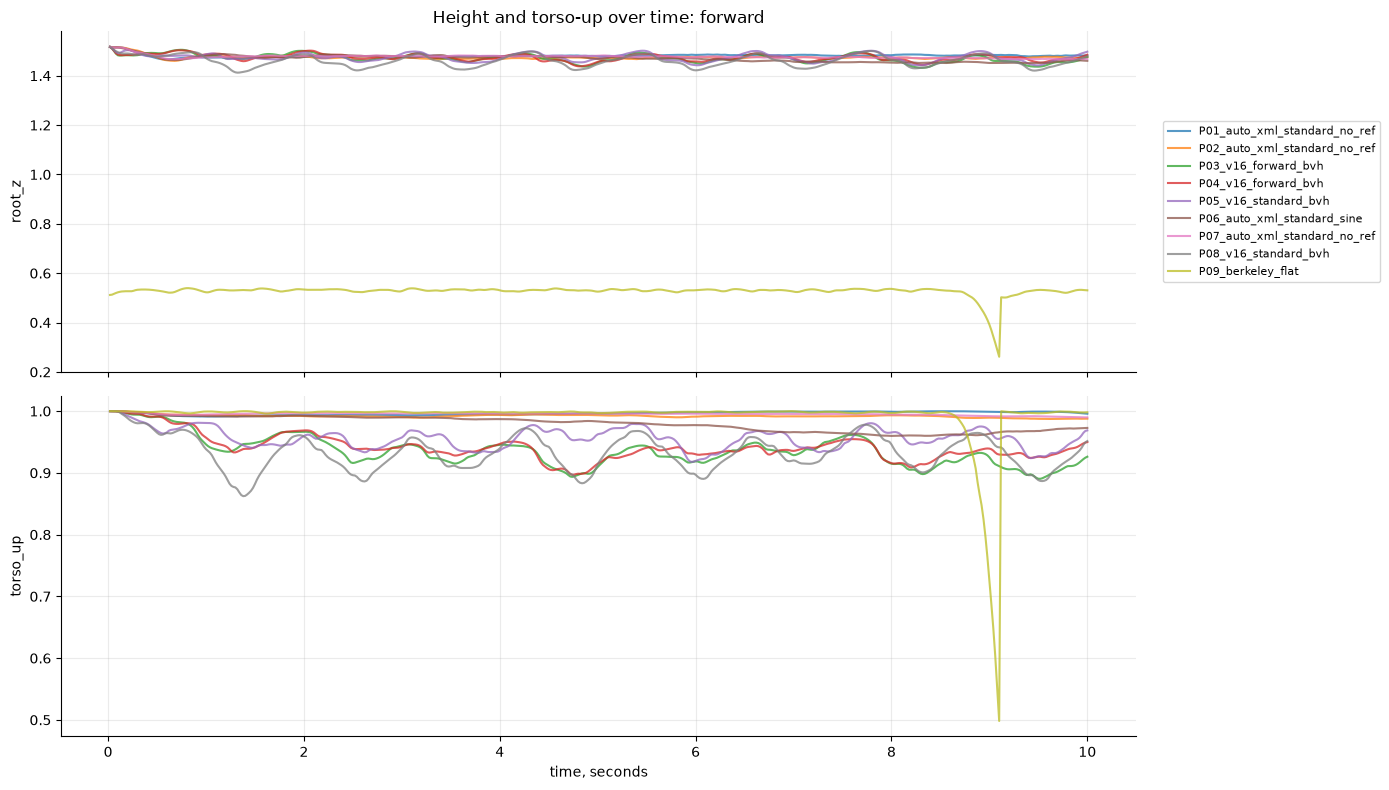

In [27]:
height_summary = (
    steps.groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(time_s=("time_s", "mean"), root_z=("root_z", "mean"), torso_up=("torso_up", "mean"))
)

selected_scenario = "forward"
subset = height_summary.loc[height_summary["scenario"].eq(selected_scenario)]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for policy_id, group in subset.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["root_z"], alpha=0.75, label=policy_id)
    axes[1].plot(group["time_s"], group["torso_up"], alpha=0.75)
axes[0].set_title(f"Height and torso-up over time: {selected_scenario}")
axes[0].set_ylabel("root_z")
axes[1].set_ylabel("torso_up")
axes[1].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_HEIGHT_POSTURE -->
### Top 3 za visinu i uspravnost na forward scenariju

| policy_id | policy_type | mean_torso_up | min_torso_up | mean_root_height | root_height_std | terminated_rate |
| --- | --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.9963 | 0.9901 | 1.4809 | 0.0068 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.9952 | 0.9888 | 1.4770 | 0.0077 | 0.0000 |
| P09_berkeley_flat | berkeley | 0.9926 | 0.6616 | 0.5260 | 0.0219 | 0.3333 |


- Najbolju forward uspravnost ima `P01_auto_xml_standard_no_ref`.
- Glatka root_z linija i visok torso_up su znak da policy ne propada u cucanj i ne gubi balans tokom hoda.


<!-- FILTERED_TOP4_HEIGHT_TORSO_NOTES -->
### Filtrirani height/torso-up: samo top 4

| policy_id | policy_type | mean_torso_up | min_torso_up | mean_root_height | root_height_std | terminated_rate |
| --- | --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.9963 | 0.9901 | 1.4809 | 0.0068 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.9952 | 0.9888 | 1.4770 | 0.0077 | 0.0000 |
| P09_berkeley_flat | berkeley | 0.9926 | 0.6616 | 0.5260 | 0.0219 | 0.3333 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.9920 | 0.9853 | 1.4747 | 0.0089 | 0.0000 |


- Prikaz je ogranicen na top 4 politike po uspravnosti na `forward` scenariju.
- Ovo je najcistiji grafikon za proveru da li policy hoda uspravno ili tone/propada tokom vremena.


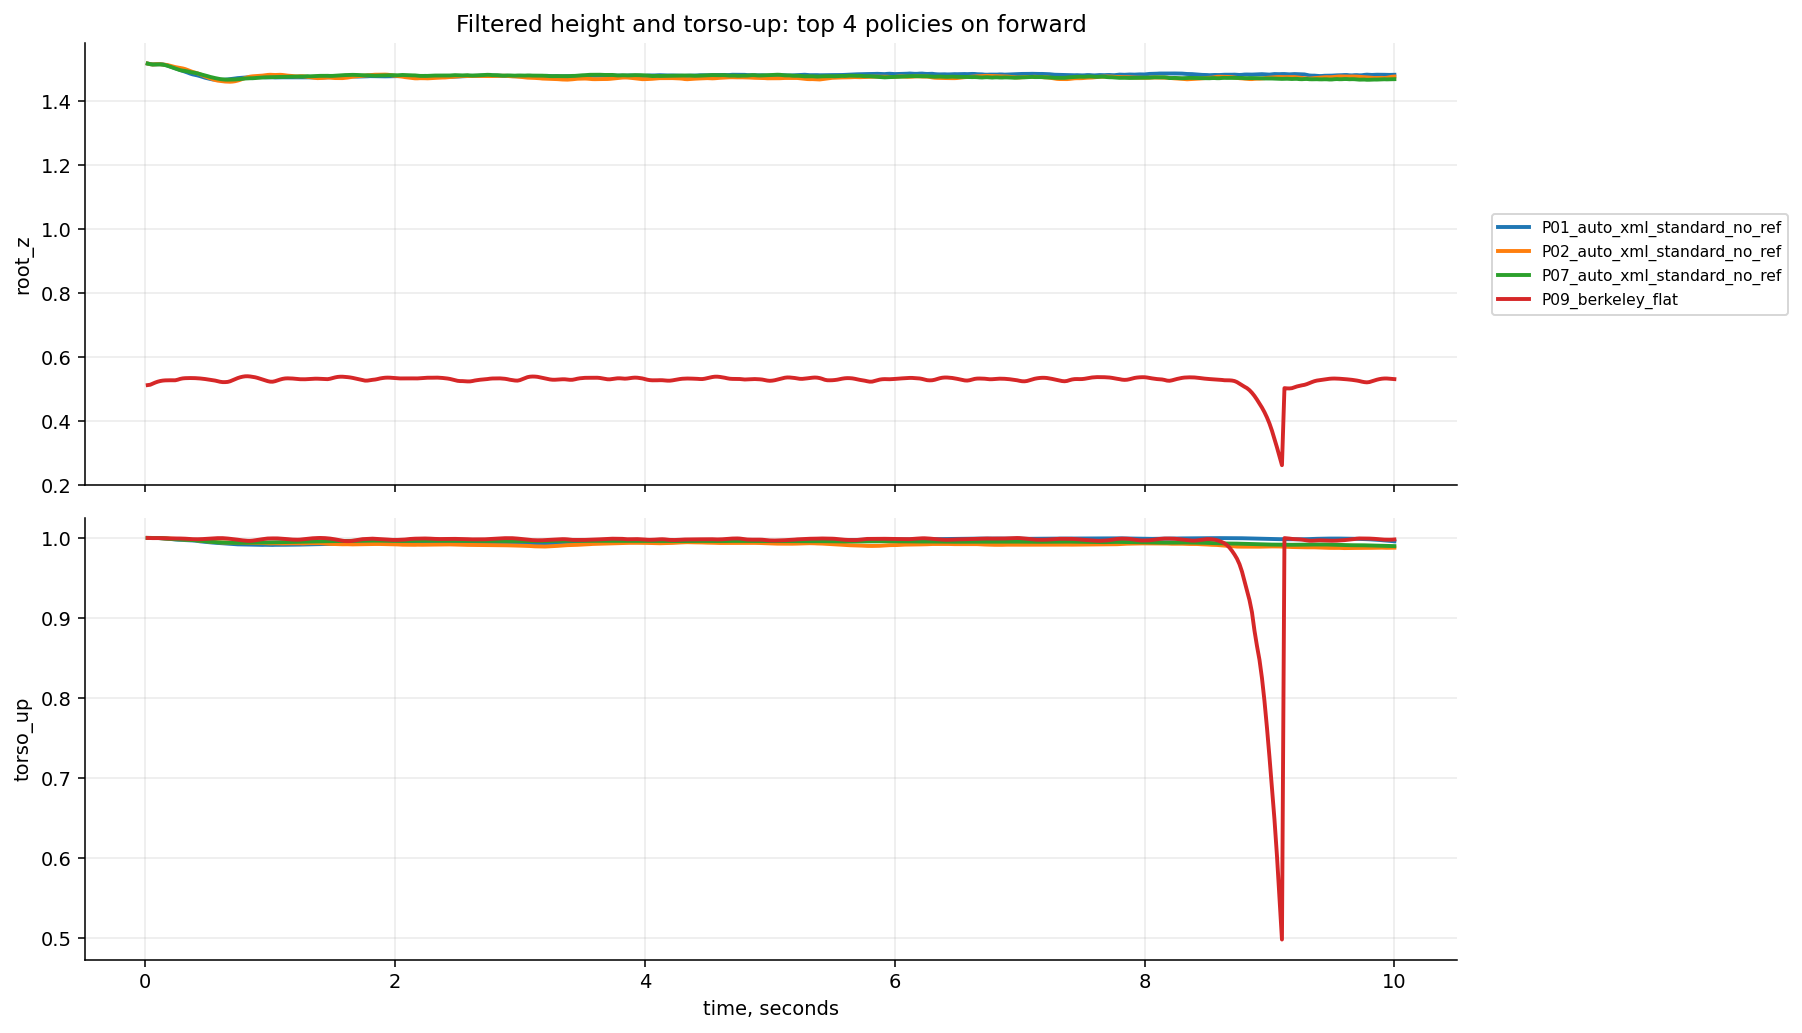

In [36]:
# Filtered height and torso-up: top 4 policies on the forward scenario.
filtered_scenario = "forward"
height_top4 = (
    episode_metrics.loc[episode_metrics["scenario"].eq(filtered_scenario)]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_torso_up=("mean_torso_up", "mean"),
        min_torso_up=("min_torso_up", "mean"),
        mean_root_height=("mean_root_height", "mean"),
        root_height_std=("root_height_std", "mean"),
        terminated_rate=("terminated", "mean"),
    )
    .sort_values(["mean_torso_up", "terminated_rate", "root_height_std"], ascending=[False, True, True])
    .head(4)
)
filtered_policies = height_top4["policy_id"].tolist()
display(height_top4)

filtered_height_summary = (
    steps.loc[
        steps["scenario"].eq(filtered_scenario)
        & steps["policy_id"].isin(filtered_policies)
    ]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(time_s=("time_s", "mean"), root_z=("root_z", "mean"), torso_up=("torso_up", "mean"))
)
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
for policy_id, group in filtered_height_summary.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["root_z"], linewidth=2.0, label=policy_id)
    axes[1].plot(group["time_s"], group["torso_up"], linewidth=2.0, label=policy_id)
axes[0].set_title(f"Filtered height and torso-up: top {len(filtered_policies)} policies on {filtered_scenario}")
axes[0].set_ylabel("root_z")
axes[1].set_ylabel("torso_up")
axes[1].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 13. Actuator analiza: gde policy trosi i saturira

In [28]:
actuator_overall = (
    actuator_metrics.groupby(["policy_id", "actuator"], as_index=False)
    .agg(
        mean_abs_action=("mean_abs_action", "mean"),
        saturation_rate=("saturation_rate", "mean"),
        motor_error_rmse=("motor_error_rmse", "mean"),
        torque_rms=("torque_rms", "mean"),
        mean_abs_power=("mean_abs_power", "mean"),
    )
)

top_power_actuators = (
    actuator_overall.sort_values("mean_abs_power", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
display_table("Top actuator power hotspots", top_power_actuators, rows=25)

### Top actuator power hotspots

,policy_id,actuator,mean_abs_action,saturation_rate,motor_error_rmse,torque_rms,mean_abs_power
0,P06_auto_xml_standard_sine,right_ankle_z,0.4141,0.0360,0.1715,20.7698,39.3492
1,P02_auto_xml_standard_no_ref,right_ankle_z,0.4176,0.0440,0.1675,20.3047,39.0355
2,P05_v16_standard_bvh,right_hip_x,0.5110,0.1960,0.4965,49.6872,38.1701
3,P08_v16_standard_bvh,right_hip_x,0.4565,0.0588,0.5151,51.5972,37.2365
4,P08_v16_standard_bvh,left_knee_z,0.4325,0.0525,0.1819,18.4684,36.0073
5,P07_auto_xml_standard_no_ref,right_ankle_z,0.4368,0.0420,0.1701,20.6333,35.6169
6,P01_auto_xml_standard_no_ref,right_ankle_z,0.4709,0.0490,0.1716,20.7790,33.4813
7,P07_auto_xml_standard_no_ref,left_knee_z,0.3090,0.0000,0.4619,50.6265,32.2598
8,P04_v16_forward_bvh,right_hip_x,0.5705,0.0800,0.4525,45.3200,31.5147
9,P07_auto_xml_standard_no_ref,left_ankle_z,0.8157,0.1363,0.1466,17.4684,30.9715


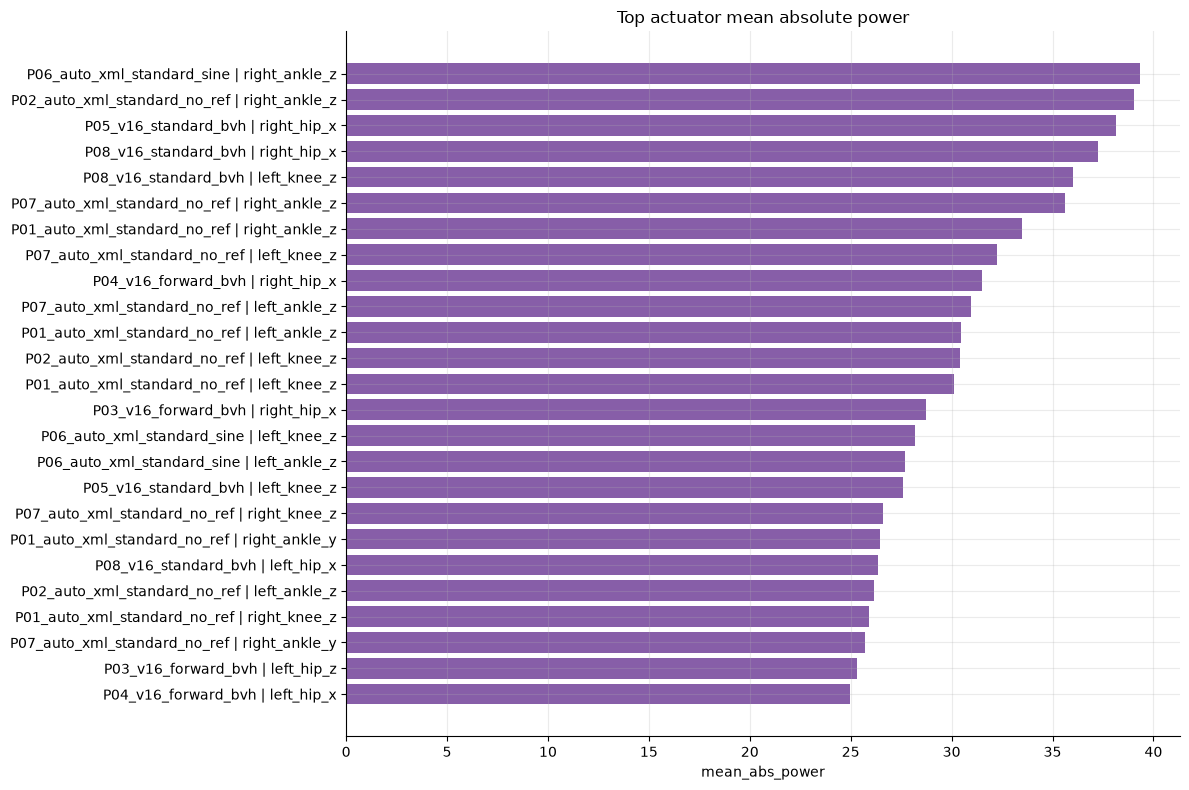

In [29]:
if not top_power_actuators.empty:
    plot_data = top_power_actuators.sort_values("mean_abs_power", ascending=True).copy()
    plot_data["label"] = plot_data["policy_id"] + " | " + plot_data["actuator"]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(plot_data["label"], plot_data["mean_abs_power"], color="#7a4c9f", alpha=0.9)
    ax.set_title("Top actuator mean absolute power")
    ax.set_xlabel("mean_abs_power")
    plt.tight_layout()
    plt.show()

<!-- NOTEBOOK_TOP3_ACTUATOR_POWER -->
### Top 3 actuator power hotspot-a

| policy_id | actuator | mean_abs_power | torque_rms | mean_abs_action | saturation_rate |
| --- | --- | --- | --- | --- | --- |
| P06_auto_xml_standard_sine | right_ankle_z | 39.3492 | 20.7698 | 0.4141 | 0.0360 |
| P02_auto_xml_standard_no_ref | right_ankle_z | 39.0355 | 20.3047 | 0.4176 | 0.0440 |
| P05_v16_standard_bvh | right_hip_x | 38.1701 | 49.6872 | 0.5110 | 0.1960 |


- Najveci power hotspot je `right_ankle_z` kod `P06_auto_xml_standard_sine`.
- Ovi aktuatori najvise nose cenu hoda; ako su i saturirani, to je znak da policy forsira granice kontrole.


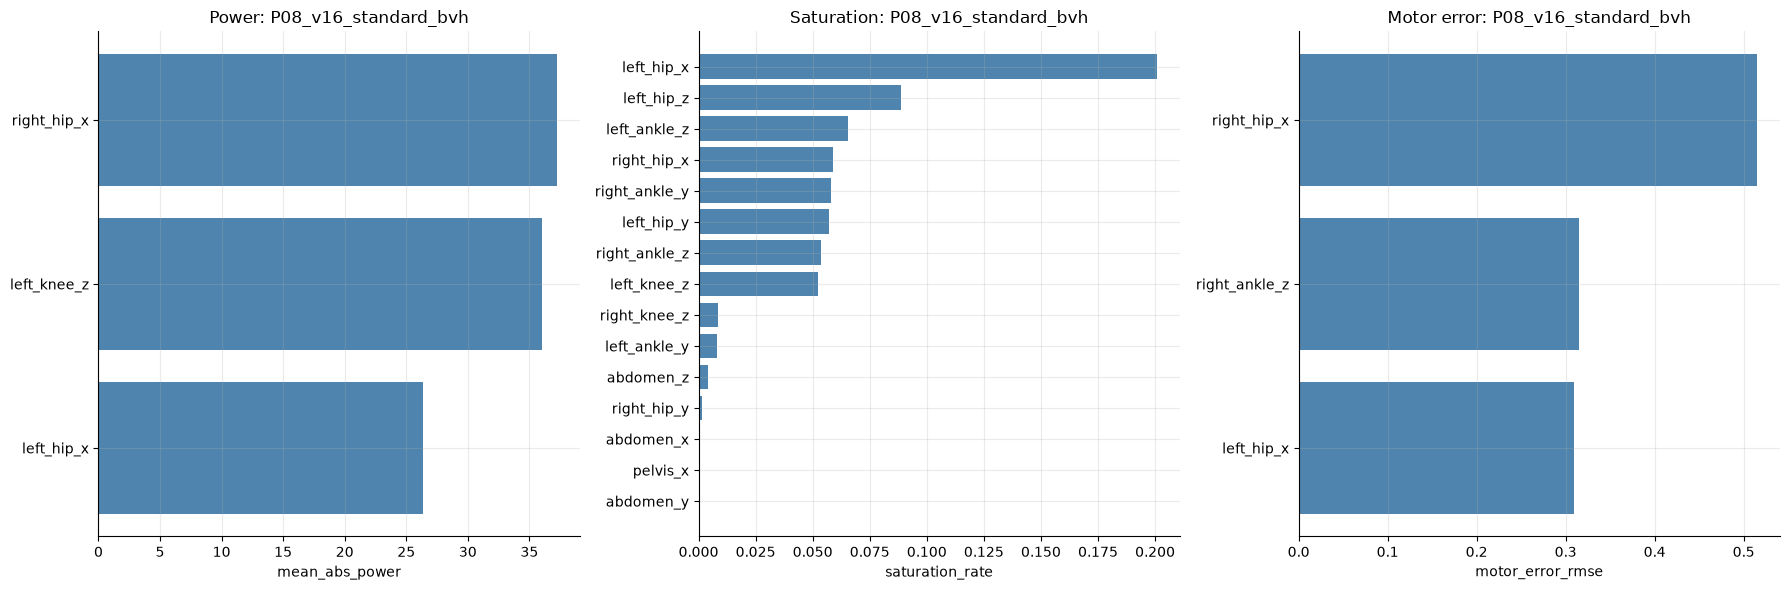

In [30]:
best_policy_id = leaderboard.iloc[0]["policy_id"] if not leaderboard.empty else actuator_overall["policy_id"].iloc[0]
best_actuators = actuator_overall.loc[actuator_overall["policy_id"].eq(best_policy_id)].sort_values("mean_abs_power", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric, title in zip(
    axes,
    ["mean_abs_power", "saturation_rate", "motor_error_rmse"],
    ["Power", "Saturation", "Motor error"],
    strict=True,
):
    subset = best_actuators.sort_values(metric, ascending=True).tail(15)
    ax.barh(subset["actuator"], subset[metric], color="#2f6f9f", alpha=0.85)
    ax.set_title(f"{title}: {best_policy_id}")
    ax.set_xlabel(metric)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_BEST_POLICY_ACTUATORS -->
### Top 3 actuator dijagnostika za najbolji policy: P08_v16_standard_bvh

| metric | actuator | value | mean_abs_power | saturation_rate | motor_error_rmse |
| --- | --- | --- | --- | --- | --- |
| mean_abs_power | right_hip_x | 37.2365 | 37.2365 | 0.0588 | 0.5151 |
| mean_abs_power | left_knee_z | 36.0073 | 36.0073 | 0.0525 | 0.1819 |
| mean_abs_power | left_hip_x | 26.3591 | 26.3591 | 0.2008 | 0.3089 |
| saturation_rate | left_hip_x | 0.2008 | 26.3591 | 0.2008 | 0.3089 |
| saturation_rate | left_hip_z | 0.0887 | 11.2896 | 0.0887 | 0.1115 |
| saturation_rate | left_ankle_z | 0.0657 | 15.0899 | 0.0657 | 0.2373 |
| motor_error_rmse | right_hip_x | 0.5151 | 37.2365 | 0.0588 | 0.5151 |
| motor_error_rmse | right_ankle_z | 0.3151 | 20.0864 | 0.0538 | 0.3151 |
| motor_error_rmse | left_hip_x | 0.3089 | 26.3591 | 0.2008 | 0.3089 |


- Ova tabela odvaja tri najjaca aktuatora po power-u, saturaciji i motor error-u za najbolji policy.
- Ako isti aktuator iskace u vise metrika, to je dobro mesto za pregled limitiranja akcija, jacine motora ili reward kazne za effort.


## 14. Raw rollout table explorer

Koristi ovo kad hoces da proveris konkretne kolone iz simulacije: qpos/qvel, joints, actions, torques, contacts i metrike iz environment-a.

In [31]:
important_step_columns = [
    "policy_id",
    "scenario",
    "seed",
    "scenario_step",
    "time_s",
    "reward",
    "done",
    "command_x",
    "command_y",
    "command_yaw",
    "measured_command_x",
    "measured_command_y",
    "measured_command_yaw",
    "command_error_norm",
    "root_x",
    "root_y",
    "root_z",
    "torso_up",
    "left_foot_contact",
    "right_foot_contact",
    "action_norm",
    "action_rate_norm",
    "mechanical_power_abs",
    "foot_slip_speed",
]
available_step_columns = [column for column in important_step_columns if column in steps.columns]
display(steps[available_step_columns].head(30))
print(f"Total rollout columns: {len(steps.columns)}")

,policy_id,scenario,seed,scenario_step,time_s,reward,done,command_x,command_y,command_yaw,measured_command_x,measured_command_y,measured_command_yaw,command_error_norm,root_x,root_y,root_z,torso_up,left_foot_contact,right_foot_contact,action_norm,action_rate_norm,mechanical_power_abs,foot_slip_speed
0,P01_auto_xml_standard_no_ref,diagonal,7,0,0.0200,-2.8313,0,0.2500,0.1500,0.2500,0.0017,0.0128,-0.0310,0.3993,0.0000,-0.0001,1.5168,1.0000,1.0000,1.0000,2.0656,0.0000,182.0118,0.0000
1,P01_auto_xml_standard_no_ref,diagonal,7,1,0.0400,-1.8380,0,0.2500,0.1500,0.2500,-0.0232,0.0613,0.1773,0.2963,-0.0003,-0.0010,1.5138,1.0000,1.0000,1.0000,2.4168,105.9543,220.0874,0.3712
2,P01_auto_xml_standard_no_ref,diagonal,7,2,0.0600,-1.7002,0,0.2500,0.1500,0.2500,-0.0097,0.1224,0.2592,0.2613,-0.0007,-0.0030,1.5114,1.0000,1.0000,1.0000,2.0112,79.6778,282.2389,0.2590
3,P01_auto_xml_standard_no_ref,diagonal,7,3,0.0800,-2.2116,0,0.2500,0.1500,0.2500,0.0157,0.1611,0.2037,0.2391,-0.0006,-0.0059,1.5113,0.9999,1.0000,1.0000,2.0369,31.4648,645.0902,0.2784
4,P01_auto_xml_standard_no_ref,diagonal,7,4,0.1000,-1.4113,0,0.2500,0.1500,0.2500,0.0319,0.1820,0.1881,0.2290,-0.0002,-0.0095,1.5119,0.9997,1.0000,1.0000,1.9217,33.5505,247.5147,0.2693
5,P01_auto_xml_standard_no_ref,diagonal,7,5,0.1200,-0.6180,0,0.2500,0.1500,0.2500,0.0456,0.1819,0.1987,0.2132,0.0005,-0.0132,1.5120,0.9992,1.0000,1.0000,1.8515,32.8896,272.0934,0.2870
6,P01_auto_xml_standard_no_ref,diagonal,7,6,0.1400,0.4415,0,0.2500,0.1500,0.2500,0.0657,0.1835,0.2002,0.1939,0.0015,-0.0168,1.5107,0.9983,1.0000,1.0000,1.8655,32.2831,224.1025,0.4718
7,P01_auto_xml_standard_no_ref,diagonal,7,7,0.1600,0.9367,0,0.2500,0.1500,0.2500,0.0868,0.1946,0.1725,0.1861,0.0030,-0.0205,1.5083,0.9971,1.0000,1.0000,1.7414,32.8556,121.2399,0.3902
8,P01_auto_xml_standard_no_ref,diagonal,7,8,0.1800,0.7866,0,0.2500,0.1500,0.2500,0.0996,0.1963,0.2007,0.1649,0.0047,-0.0242,1.5044,0.9957,1.0000,1.0000,1.7450,26.0075,133.6769,0.3415
9,P01_auto_xml_standard_no_ref,diagonal,7,9,0.2000,1.4662,0,0.2500,0.1500,0.2500,0.1239,0.2018,0.1979,0.1460,0.0067,-0.0281,1.5005,0.9942,1.0000,1.0000,1.8154,28.5536,182.0637,0.3188


Total rollout columns: 469


In [32]:
prefix_counts = []
for prefix in ["qpos_", "qvel_", "joint_pos_", "joint_vel_", "action_", "motor_target_", "motor_error_", "torque_", "power_", "env_metric_", "info_"]:
    prefix_counts.append({"prefix": prefix, "columns": sum(column.startswith(prefix) for column in steps.columns)})
pd.DataFrame(prefix_counts)

,prefix,columns
0,qpos_,40
1,qvel_,39
2,joint_pos_,45
3,joint_vel_,45
4,action_,36
5,motor_target_,31
6,motor_error_,30
7,torque_,30
8,power_,30
9,env_metric_,44


## 15. Export dodatnih notebook tabela

In [33]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

leaderboard.to_csv(OUTPUT_DIR / "notebook_in_distribution_leaderboard.csv", index=False)
overall_scenario_score.to_csv(OUTPUT_DIR / "notebook_overall_scenario_score.csv", index=False)
scenario_leaders.to_csv(OUTPUT_DIR / "notebook_scenario_top3.csv", index=False)
top_power_actuators.to_csv(OUTPUT_DIR / "notebook_top_power_actuators.csv", index=False)

print(f"Saved notebook summary CSVs to: {OUTPUT_DIR}")

Saved notebook summary CSVs to: c:\Users\aleks\Desktop\Aleksie kerefeke\master\RS projekat - RL politika ucenja joystick\mujoco-bipedal-joystick-walker\analysis_outputs


## 16. Kako iz ovoga izvuci zakljucak

Za rad/izvestaj najjaci redosled je:

1. `In-distribution policy leaderboard` za glavni ranking.
2. `Composite score by policy and scenario` da vidis generalizaciju po komandama.
3. `Mean survival fraction` i `Total falls` da proveris robustnost.
4. `Tracking RMSE` da odvojis stabilno hodanje od stvarnog pracenja joystick komande.
5. `Smoothness vs mechanical power` i actuator hotspots da vidis cenu hoda.

Ako policy ima dobar reward iz treninga, ali los scenario score ili survival, to je znak da je naucen usko za svoj training setup. Drugim recima: broj izgleda dobro, ali hod jos nije dovoljno pouzdan za opsti zakljucak.